<a href="https://colab.research.google.com/github/hemel5612-lgtm/Aleurodicus-rugioperculatus/blob/main/Spodoptera_frugiperda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# STEP 1: Install & Import
!pip install openpyxl statsmodels pingouin -q

import pandas as pd
import numpy as np
import os
import warnings
warnings.filterwarnings('ignore')

# ── Mount Google Drive ────────────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

# ── File paths ────────────────────────────────────────────────────────────
FILE      = '/content/drive/MyDrive/Data Analysis March 2026/Raina/Spodoptera frugiperda/Final_Dataset.xlsx'
OUT_TABLE = '/content/drive/MyDrive/Data Analysis March 2026/Raina/Spodoptera frugiperda/Outputs/Tables'
OUT_FIG   = '/content/drive/MyDrive/Data Analysis March 2026/Raina/Spodoptera frugiperda/Outputs/Figures'

# ── Create output folders if they don't exist ─────────────────────────────
os.makedirs(OUT_TABLE, exist_ok=True)
os.makedirs(OUT_FIG,   exist_ok=True)
print("✓ Output folders ready")
print(f"  Tables  → {OUT_TABLE}")
print(f"  Figures → {OUT_FIG}")

# ── Load all sheets ───────────────────────────────────────────────────────
xl = pd.ExcelFile(FILE)

print("\n" + "=" * 55)
print("  Sheet names found:")
print("=" * 55)
for s in xl.sheet_names:
    print(f"  • {s}")

sheets = {}
for s in xl.sheet_names:
    sheets[s] = pd.read_excel(FILE, sheet_name=s)

print("\n" + "=" * 55)
print("  Shape & Columns per Sheet:")
print("=" * 55)
for name, df in sheets.items():
    print(f"\n── {name} ──")
    print(f"   Rows × Cols : {df.shape}")
    print(f"   Columns     : {list(df.columns)}")
    print(f"   Missing vals: {df.isnull().sum().sum()}")
    print(df.head(3).to_string(index=False))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✓ Output folders ready
  Tables  → /content/drive/MyDrive/Data Analysis March 2026/Raina/Spodoptera frugiperda/Outputs/Tables
  Figures → /content/drive/MyDrive/Data Analysis March 2026/Raina/Spodoptera frugiperda/Outputs/Figures

  Sheet names found:
  • syn_cannibalism_diff
  • syn_cannibalism_same
  • syn_leaf_diff
  • syn_leaf_same
  • syn_pupal_weight_diff
  • syn_pupal_weight_same

  Shape & Columns per Sheet:

── syn_cannibalism_diff ──
   Rows × Cols : (60, 22)
   Columns     : ['Treatment', 'Food_Condition', 'Instar_Condition', 'No. of Larvae', 'Replication', 'Day1', 'Day2', 'Day3', 'Day4', 'Day5', 'Day6', 'Day7', 'Day8', 'Day9', 'Day10', 'Day11', 'Day12', 'Day13', 'Day14', 'Day15', 'Day16', 'Day17']
   Missing vals: 0
Treatment Food_Condition Instar_Condition  No. of Larvae  Replication  Day1  Day2  Day3  Day4  Day5  Day6  Day7  Day8  Day9  Day10  D

In [2]:
# STEP 2: Assign sheets and compute all derived variables

DAY_COLS = [f'Day{i}' for i in range(1, 18)]
META     = ['Treatment', 'Food_Condition', 'Instar_Condition', 'No. of Larvae', 'Replication']

# ── Assign each sheet to a named variable ────────────────────────────────
cb_diff = sheets['syn_cannibalism_diff'].copy()
cb_same = sheets['syn_cannibalism_same'].copy()
lc_diff = sheets['syn_leaf_diff'].copy()
lc_same = sheets['syn_leaf_same'].copy()
pw_diff = sheets['syn_pupal_weight_diff'].copy()
pw_same = sheets['syn_pupal_weight_same'].copy()

# ── Rename weight columns for clean access ────────────────────────────────
for df in [pw_same, pw_diff]:
    df.rename(columns={
        'Initial Weight': 'Initial_Weight',
        'Final Weight'  : 'Final_Weight'
    }, inplace=True)

# ─────────────────────────────────────────────────────────────────────────
# DERIVED VARIABLE 1: Total Cannibalism & Cannibalism Proportion
# ─────────────────────────────────────────────────────────────────────────
for df in [cb_same, cb_diff]:
    df['Total_Cannibalism'] = df[DAY_COLS].sum(axis=1)
    df['Cannibalism_Prop']  = (df['Total_Cannibalism'] / df['No. of Larvae']).clip(0, 1)

# ─────────────────────────────────────────────────────────────────────────
# DERIVED VARIABLE 2: Survival Rate
# survivors = total larvae - cannibalized - non-cannibalism deaths
# ─────────────────────────────────────────────────────────────────────────
for df in [cb_same, cb_diff]:
    df['Death_Prob']      = (0.05 + 0.02 * df['No. of Larvae']).clip(upper=0.25)
    df['NC_Deaths']       = (df['Death_Prob'] * (df['No. of Larvae'] - df['Total_Cannibalism'])).clip(lower=0)
    df['Survivors']       = (df['No. of Larvae'] - df['Total_Cannibalism'] - df['NC_Deaths']).clip(lower=0)
    df['Survival_Rate']   = (df['Survivors'] / df['No. of Larvae']).clip(0, 1)

# ─────────────────────────────────────────────────────────────────────────
# DERIVED VARIABLE 3: Total Leaf Consumption
# ─────────────────────────────────────────────────────────────────────────
for df in [lc_same, lc_diff]:
    df['Total_LC'] = df[DAY_COLS].sum(axis=1)

# ─────────────────────────────────────────────────────────────────────────
# DERIVED VARIABLE 4: Larval Period (last day with consumption > 0)
# ─────────────────────────────────────────────────────────────────────────
def estimate_larval_period(row):
    for d in range(16, -1, -1):
        if row[DAY_COLS[d]] > 0:
            return d + 1
    return np.nan

for df in [lc_same, lc_diff]:
    df['Larval_Period'] = df.apply(estimate_larval_period, axis=1)

# ─────────────────────────────────────────────────────────────────────────
# PUPAL WEIGHT: separate alive (Final_Weight > 0) from dead
# ─────────────────────────────────────────────────────────────────────────
pw_same_alive = pw_same[pw_same['Final_Weight'] > 0].copy()
pw_diff_alive = pw_diff[pw_diff['Final_Weight'] > 0].copy()

# ─────────────────────────────────────────────────────────────────────────
# PRINT SUMMARY
# ─────────────────────────────────────────────────────────────────────────
print("=" * 60)
print("  DERIVED VARIABLES SUMMARY")
print("=" * 60)

print("\n── Cannibalism (Same Instar) ─────────────────────────────────")
print(cb_same.groupby(['Food_Condition', 'Treatment'])[
    ['Cannibalism_Prop', 'Survival_Rate']
].mean().round(3).to_string())

print("\n── Cannibalism (Different Instar) ───────────────────────────")
print(cb_diff.groupby(['Food_Condition', 'Treatment'])[
    ['Cannibalism_Prop', 'Survival_Rate']
].mean().round(3).to_string())

print("\n── Leaf Consumption (Same Instar) ───────────────────────────")
print(lc_same.groupby(['Food_Condition', 'Treatment'])[
    ['Total_LC', 'Larval_Period']
].mean().round(2).to_string())

print("\n── Leaf Consumption (Different Instar) ──────────────────────")
print(lc_diff.groupby(['Food_Condition', 'Treatment'])[
    ['Total_LC', 'Larval_Period']
].mean().round(2).to_string())

print("\n── Pupal Weight — Same Instar (alive only) ──────────────────")
print(f"   Total rows alive : {len(pw_same_alive)}  |  Dead (Final=0): {len(pw_same) - len(pw_same_alive)}")
print(pw_same_alive.groupby(['Food_Condition', 'Treatment'])[
    ['Initial_Weight', 'Final_Weight']
].mean().round(4).to_string())

print("\n── Pupal Weight — Different Instar (alive only) ─────────────")
print(f"   Total rows alive : {len(pw_diff_alive)}  |  Dead (Final=0): {len(pw_diff) - len(pw_diff_alive)}")
print(pw_diff_alive.groupby(['Food_Condition', 'Treatment', 'Instar_Condition'])[
    'Final_Weight'
].mean().round(4).to_string())

print("\n✓ All derived variables computed successfully")

  DERIVED VARIABLES SUMMARY

── Cannibalism (Same Instar) ─────────────────────────────────
                          Cannibalism_Prop  Survival_Rate
Food_Condition Treatment                                 
Insufficient   Control               0.200          0.744
               T1                    0.300          0.637
               T2                    0.500          0.435
               T3                    0.862          0.109
Sufficient     Control               0.000          0.930
               T1                    0.050          0.864
               T2                    0.150          0.739
               T3                    0.488          0.405

── Cannibalism (Different Instar) ───────────────────────────
                          Cannibalism_Prop  Survival_Rate
Food_Condition Treatment                                 
Insufficient   Control               0.250          0.697
               T1                    0.417          0.531
               T2                

In [3]:
# STEP 3: Descriptive Statistics Tables
import pandas as pd
import numpy as np

TRT_ORDER  = ['Control', 'T1', 'T2', 'T3']
FOOD_ORDER = ['Sufficient', 'Insufficient']
OUT_TABLE  = '/content/drive/MyDrive/Data Analysis March 2026/Raina/Spodoptera frugiperda/Outputs/Tables'

def desc_table(df, value_col, group_cols):
    tbl = df.groupby(group_cols)[value_col].agg(
        N    = 'count',
        Mean = 'mean',
        SD   = 'std',
        SE   = lambda x: x.std() / np.sqrt(len(x)),
        Min  = 'min',
        Max  = 'max'
    ).round(4).reset_index()
    tbl['Mean_SD'] = tbl.apply(lambda r: str(round(r['Mean'],4)) + ' +/- ' + str(round(r['SD'],4)), axis=1)
    tbl['Mean_SE'] = tbl.apply(lambda r: str(round(r['Mean'],4)) + ' +/- ' + str(round(r['SE'],4)), axis=1)
    return tbl

def sort_tbl(tbl, trt_cats):
    tbl['Treatment']      = pd.Categorical(tbl['Treatment'],      categories=trt_cats,   ordered=True)
    tbl['Food_Condition'] = pd.Categorical(tbl['Food_Condition'], categories=FOOD_ORDER, ordered=True)
    return tbl.sort_values(['Food_Condition', 'Treatment']).reset_index(drop=True)

DISPLAY = ['Food_Condition', 'Treatment', 'N', 'Mean_SD', 'Min', 'Max']

# TABLE 1: Cannibalism Proportion - Same Instar
t1 = desc_table(cb_same, 'Cannibalism_Prop', ['Food_Condition', 'Treatment'])
t1 = sort_tbl(t1, TRT_ORDER)
print('=' * 65)
print('  TABLE 1: Cannibalism Proportion - Same Instar (L2 x L2)')
print('=' * 65)
print(t1[DISPLAY].to_string(index=False))

# TABLE 2: Cannibalism Proportion - Different Instar
cb_diff_mixed = cb_diff[cb_diff['Instar_Condition'] == 'Different'].copy()
t2 = desc_table(cb_diff_mixed, 'Cannibalism_Prop', ['Food_Condition', 'Treatment'])
t2 = sort_tbl(t2, ['T1', 'T2', 'T3'])
print('\n' + '=' * 65)
print('  TABLE 2: Cannibalism Proportion - Different Instar (L2+L5)')
print('=' * 65)
print(t2[DISPLAY].to_string(index=False))

# TABLE 3: Survival Rate - Same Instar
t3 = desc_table(cb_same, 'Survival_Rate', ['Food_Condition', 'Treatment'])
t3 = sort_tbl(t3, TRT_ORDER)
print('\n' + '=' * 65)
print('  TABLE 3: Survival Rate - Same Instar (L2 x L2)')
print('=' * 65)
print(t3[DISPLAY].to_string(index=False))

# TABLE 4: Survival Rate - Different Instar
t4 = desc_table(cb_diff_mixed, 'Survival_Rate', ['Food_Condition', 'Treatment'])
t4 = sort_tbl(t4, ['T1', 'T2', 'T3'])
print('\n' + '=' * 65)
print('  TABLE 4: Survival Rate - Different Instar (L2+L5)')
print('=' * 65)
print(t4[DISPLAY].to_string(index=False))

# TABLE 5: Pupal Weight - Same Instar (survivors only)
t5 = desc_table(pw_same_alive, 'Final_Weight', ['Food_Condition', 'Treatment'])
t5 = sort_tbl(t5, TRT_ORDER)
print('\n' + '=' * 65)
print('  TABLE 5: Pupal Weight (g) - Same Instar (survivors only)')
print('=' * 65)
print(t5[DISPLAY].to_string(index=False))

# TABLE 6a: Pupal Weight - Different Instar Controls
pw_diff_ctrl = pw_diff_alive[pw_diff_alive['Treatment'] == 'Control'].copy()
t6a = desc_table(pw_diff_ctrl, 'Final_Weight', ['Food_Condition', 'Instar_Condition'])
print('\n' + '=' * 65)
print('  TABLE 6a: Pupal Weight (g) - Diff Instar Controls')
print('=' * 65)
print(t6a[['Food_Condition','Instar_Condition','N','Mean_SD','Min','Max']].to_string(index=False))

# TABLE 6b: Pupal Weight - Different Instar T1-T3
pw_diff_mixed = pw_diff_alive[pw_diff_alive['Treatment'] != 'Control'].copy()
t6b = desc_table(pw_diff_mixed, 'Final_Weight', ['Food_Condition', 'Treatment'])
t6b = sort_tbl(t6b, ['T1','T2','T3'])
print('\n' + '=' * 65)
print('  TABLE 6b: Pupal Weight (g) - Diff Instar T1-T3')
print('=' * 65)
print(t6b[DISPLAY].to_string(index=False))

# TABLE 7: Larval Period - Same Instar
lc_same_valid = lc_same.dropna(subset=['Larval_Period']).copy()
t7 = desc_table(lc_same_valid, 'Larval_Period', ['Food_Condition', 'Treatment'])
t7 = sort_tbl(t7, TRT_ORDER)
print('\n' + '=' * 65)
print('  TABLE 7: Larval Period (days) - Same Instar')
print('=' * 65)
print(t7[DISPLAY].to_string(index=False))

# TABLE 8: Larval Period - Different Instar
lc_diff_valid = lc_diff.dropna(subset=['Larval_Period']).copy()
t8 = desc_table(lc_diff_valid, 'Larval_Period', ['Food_Condition', 'Instar_Condition', 'Treatment'])
print('\n' + '=' * 65)
print('  TABLE 8: Larval Period (days) - Different Instar')
print('=' * 65)
print(t8[['Food_Condition','Instar_Condition','Treatment','N','Mean_SD','Min','Max']].to_string(index=False))

# TABLE 9: Total Leaf Consumption - Same Instar
t9 = desc_table(lc_same, 'Total_LC', ['Food_Condition', 'Treatment'])
t9 = sort_tbl(t9, TRT_ORDER)
print('\n' + '=' * 65)
print('  TABLE 9: Total Leaf Consumption (%) - Same Instar')
print('=' * 65)
print(t9[DISPLAY].to_string(index=False))

# TABLE 10: Total Leaf Consumption - Different Instar
t10 = desc_table(lc_diff, 'Total_LC', ['Food_Condition', 'Instar_Condition', 'Treatment'])
print('\n' + '=' * 65)
print('  TABLE 10: Total Leaf Consumption (%) - Different Instar')
print('=' * 65)
print(t10[['Food_Condition','Instar_Condition','Treatment','N','Mean_SD','Min','Max']].to_string(index=False))

# SAVE ALL TABLES TO EXCEL
save_path = OUT_TABLE + '/Descriptive_Statistics.xlsx'
tables = {
    'T1_CB_Same'   : t1,
    'T2_CB_Diff'   : t2,
    'T3_Surv_Same' : t3,
    'T4_Surv_Diff' : t4,
    'T5_PW_Same'   : t5,
    'T6a_PW_DiffCtrl': t6a,
    'T6b_PW_DiffTrt' : t6b,
    'T7_LP_Same'   : t7,
    'T8_LP_Diff'   : t8,
    'T9_LC_Same'   : t9,
    'T10_LC_Diff'  : t10,
}
with pd.ExcelWriter(save_path, engine='openpyxl') as writer:
    for sheet_name, df in tables.items():
        df.to_excel(writer, sheet_name=sheet_name, index=False)
print('\n' + '=' * 65)
print('  ALL TABLES SAVED TO:')
print('  ' + save_path)
print('=' * 65)

  TABLE 1: Cannibalism Proportion - Same Instar (L2 x L2)
Food_Condition Treatment  N           Mean_SD   Min  Max
    Sufficient   Control 10       0.0 +/- 0.0 0.000 0.00
    Sufficient        T1 10   0.05 +/- 0.1581 0.000 0.50
    Sufficient        T2 10   0.15 +/- 0.1291 0.000 0.25
    Sufficient        T3 10 0.4875 +/- 0.1905 0.125 0.75
  Insufficient   Control 10    0.2 +/- 0.4216 0.000 1.00
  Insufficient        T1 10    0.3 +/- 0.3496 0.000 1.00
  Insufficient        T2 10    0.5 +/- 0.2041 0.250 0.75
  Insufficient        T3 10 0.8625 +/- 0.1094 0.625 1.00

  TABLE 2: Cannibalism Proportion - Different Instar (L2+L5)
Food_Condition Treatment  N           Mean_SD    Min  Max
    Sufficient        T1  6   0.25 +/- 0.2739 0.0000  0.5
    Sufficient        T2  6  0.125 +/- 0.2092 0.0000  0.5
    Sufficient        T3  6 0.3056 +/- 0.1948 0.0000  0.5
  Insufficient        T1  6 0.4167 +/- 0.2041 0.0000  0.5
  Insufficient        T2  6 0.4583 +/- 0.1021 0.2500  0.5
  Insufficient     

In [4]:
# STEP 4: Statistical Tests
import pandas as pd
import numpy as np
from scipy.stats import shapiro, levene, kruskal, mannwhitneyu
from statsmodels.formula.api import ols, glm
from statsmodels.stats.anova import anova_lm
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import statsmodels.api as sm
from itertools import combinations
import warnings
warnings.filterwarnings('ignore')

OUT_TABLE  = '/content/drive/MyDrive/Data Analysis March 2026/Raina/Spodoptera frugiperda/Outputs/Tables'
TRT_ORDER  = ['Control', 'T1', 'T2', 'T3']
FOOD_ORDER = ['Sufficient', 'Insufficient']
results_all = []
SEP = '=' * 65

# =========================================================
# HELPER FUNCTIONS
# =========================================================

def check_normality(df, value_col, group_cols, label):
    print(SEP)
    print('  Shapiro-Wilk Normality: ' + label)
    print(SEP)
    all_groups = []
    for key, grp in df.groupby(group_cols)[value_col]:
        vals = grp.dropna().values
        if len(vals) >= 3:
            W2, p = shapiro(vals)
            tag  = 'Normal' if p > 0.05 else 'NOT Normal'
            kstr = str(key) if not isinstance(key, tuple) else ' | '.join(str(k) for k in key)
            print('  ' + kstr + '  W=' + str(round(W2,4)) + '  p=' + str(round(p,4)) + '  ' + tag)
            all_groups.append(vals)
    if len(all_groups) > 1:
        stat, p_lev = levene(*all_groups)
        tag2 = 'EQUAL' if p_lev > 0.05 else 'UNEQUAL'
        print('  Levene: F=' + str(round(stat,4)) + '  p=' + str(round(p_lev,4)) + '  -> ' + tag2 + ' variances')


def sig_label(p):
    if   p < 0.001: return '***'
    elif p < 0.01:  return '**'
    elif p < 0.05:  return '*'
    else:           return 'ns'


def kruskal_posthoc(df, value_col, group_col, label, order=None):
    print(SEP)
    print('  Kruskal-Wallis: ' + label)
    print(SEP)
    ugroups = order if order else list(df[group_col].unique())
    ugroups = [g for g in ugroups if g in df[group_col].values]
    arrays  = [df[df[group_col]==g][value_col].dropna().values for g in ugroups]
    arrays  = [a for a in arrays if len(a) > 0]
    if len(arrays) < 2:
        print('  Not enough groups - skipped')
        return None, None
    H, p = kruskal(*arrays)
    print('  H=' + str(round(H,4)) + '  p=' + str(round(p,4)) + '  ' + sig_label(p))
    results_all.append({'Test':'Kruskal-Wallis','Variable':label,'H':round(H,4),'p':round(p,4),'Sig':sig_label(p)})
    if p < 0.05:
        print('  Post-hoc Mann-Whitney U (pairwise):')
        for (i,g1),(j,g2) in combinations(enumerate(ugroups), 2):
            a = df[df[group_col]==g1][value_col].dropna().values
            b = df[df[group_col]==g2][value_col].dropna().values
            if len(a) > 0 and len(b) > 0:
                u2, p2 = mannwhitneyu(a, b, alternative='two-sided')
                print('    ' + str(g1) + ' vs ' + str(g2) + ': U=' + str(round(u2,2)) + '  p=' + str(round(p2,4)) + '  ' + sig_label(p2))
    return H, p


def mann_whitney_food_effect(df, value_col, trt_col, label):
    print(SEP)
    print('  Mann-Whitney U (Food Effect): ' + label)
    print(SEP)
    for trt in df[trt_col].unique():
        a = df[(df[trt_col]==trt) & (df['Food_Condition']=='Sufficient')][value_col].dropna().values
        b = df[(df[trt_col]==trt) & (df['Food_Condition']=='Insufficient')][value_col].dropna().values
        if len(a) > 0 and len(b) > 0:
            u, p = mannwhitneyu(a, b, alternative='two-sided')
            print('  ' + str(trt) + ': Suf vs Insuf  U=' + str(round(u,2)) + '  p=' + str(round(p,4)) + '  ' + sig_label(p))


def two_way_anova(df, value_col, f1, f2, label):
    print(SEP)
    print('  Two-way ANOVA: ' + label)
    print(SEP)
    formula = value_col + ' ~ C(' + f1 + ') + C(' + f2 + ') + C(' + f1 + '):C(' + f2 + ')'
    model   = ols(formula, data=df).fit()
    atbl    = anova_lm(model, typ=2)
    print(atbl.round(4))
    for idx in atbl.index:
        row = atbl.loc[idx]
        p   = row['PR(>F)']
        results_all.append({'Test':'Two-way ANOVA','Variable':label,'Factor':idx,'F':round(row['F'],4),'p':round(p,4),'Sig':sig_label(p)})
    df2 = df.copy()
    df2['_g'] = df2[f1].astype(str) + '_' + df2[f2].astype(str)
    valid = df2[value_col].notna()
    print('  Tukey HSD Post-hoc (' + f1 + ' x ' + f2 + '):')
    tukey = pairwise_tukeyhsd(df2.loc[valid, value_col], df2.loc[valid, '_g'])
    print(tukey.summary())
    return atbl


# =========================================================
# SECTION 1: CANNIBALISM PROPORTION - SAME INSTAR
# =========================================================
print('#' * 65)
print('  SECTION 1: CANNIBALISM PROPORTION - SAME INSTAR')
print('#' * 65)

check_normality(cb_same, 'Cannibalism_Prop', ['Food_Condition', 'Treatment'], 'Cannibalism - Same Instar')

print(SEP)
print('  Binomial GLM: Cannibalism Proportion - Same Instar')
print(SEP)
cb_glm = cb_same.copy()
cb_glm['food_insuf'] = (cb_glm['Food_Condition'] == 'Insufficient').astype(int)
cb_glm['success']    = (cb_glm['Cannibalism_Prop'] * cb_glm['No. of Larvae']).round().astype(int)
cb_glm['failure']    = (cb_glm['No. of Larvae'] - cb_glm['success']).clip(lower=0)
glm_cb = glm('success + failure ~ food_insuf + Q("No. of Larvae") + food_insuf:Q("No. of Larvae")',
             data=cb_glm, family=sm.families.Binomial()).fit()
print(glm_cb.summary())

for food in FOOD_ORDER:
    d = cb_same[cb_same['Food_Condition'] == food]
    kruskal_posthoc(d, 'Cannibalism_Prop', 'Treatment', 'Cannibalism Same - ' + food, order=TRT_ORDER)

mann_whitney_food_effect(cb_same, 'Cannibalism_Prop', 'Treatment', 'Cannibalism - Same Instar')


# =========================================================
# SECTION 2: CANNIBALISM PROPORTION - DIFFERENT INSTAR
# =========================================================
print('#' * 65)
print('  SECTION 2: CANNIBALISM PROPORTION - DIFFERENT INSTAR')
print('#' * 65)

cb_diff_mixed = cb_diff[cb_diff['Instar_Condition'] == 'Different'].copy()
check_normality(cb_diff_mixed, 'Cannibalism_Prop', ['Food_Condition', 'Treatment'], 'Cannibalism - Diff Instar')

for food in FOOD_ORDER:
    d = cb_diff_mixed[cb_diff_mixed['Food_Condition'] == food]
    kruskal_posthoc(d, 'Cannibalism_Prop', 'Treatment', 'Cannibalism Diff - ' + food, order=['T1','T2','T3'])

mann_whitney_food_effect(cb_diff_mixed, 'Cannibalism_Prop', 'Treatment', 'Cannibalism - Diff Instar')


# =========================================================
# SECTION 3: SURVIVAL RATE - SAME INSTAR
# =========================================================
print('#' * 65)
print('  SECTION 3: SURVIVAL RATE - SAME INSTAR')
print('#' * 65)

check_normality(cb_same, 'Survival_Rate', ['Food_Condition', 'Treatment'], 'Survival Rate - Same Instar')

for food in FOOD_ORDER:
    d = cb_same[cb_same['Food_Condition'] == food]
    kruskal_posthoc(d, 'Survival_Rate', 'Treatment', 'Survival Same - ' + food, order=TRT_ORDER)

mann_whitney_food_effect(cb_same, 'Survival_Rate', 'Treatment', 'Survival Rate - Same Instar')


# =========================================================
# SECTION 4: SURVIVAL RATE - DIFFERENT INSTAR
# =========================================================
print('#' * 65)
print('  SECTION 4: SURVIVAL RATE - DIFFERENT INSTAR')
print('#' * 65)

check_normality(cb_diff_mixed, 'Survival_Rate', ['Food_Condition', 'Treatment'], 'Survival Rate - Diff Instar')

for food in FOOD_ORDER:
    d = cb_diff_mixed[cb_diff_mixed['Food_Condition'] == food]
    kruskal_posthoc(d, 'Survival_Rate', 'Treatment', 'Survival Diff - ' + food, order=['T1','T2','T3'])

mann_whitney_food_effect(cb_diff_mixed, 'Survival_Rate', 'Treatment', 'Survival Rate - Diff Instar')


# =========================================================
# SECTION 5: PUPAL WEIGHT - SAME INSTAR
# =========================================================
print('#' * 65)
print('  SECTION 5: PUPAL WEIGHT - SAME INSTAR')
print('#' * 65)

check_normality(pw_same_alive, 'Final_Weight', ['Food_Condition', 'Treatment'], 'Pupal Weight - Same Instar')
two_way_anova(pw_same_alive, 'Final_Weight', 'Food_Condition', 'Treatment', 'Pupal Weight - Same Instar')

for food in FOOD_ORDER:
    d = pw_same_alive[pw_same_alive['Food_Condition'] == food]
    kruskal_posthoc(d, 'Final_Weight', 'Treatment', 'Pupal Weight Same - ' + food, order=TRT_ORDER)

mann_whitney_food_effect(pw_same_alive, 'Final_Weight', 'Treatment', 'Pupal Weight - Same Instar')


# =========================================================
# SECTION 6: PUPAL WEIGHT - DIFFERENT INSTAR
# =========================================================
print('#' * 65)
print('  SECTION 6: PUPAL WEIGHT - DIFFERENT INSTAR')
print('#' * 65)

pw_diff_mixed = pw_diff_alive[pw_diff_alive['Treatment'] != 'Control'].copy()
check_normality(pw_diff_mixed, 'Final_Weight', ['Food_Condition', 'Treatment'], 'Pupal Weight - Diff Instar')
two_way_anova(pw_diff_mixed, 'Final_Weight', 'Food_Condition', 'Treatment', 'Pupal Weight - Diff Instar')

mann_whitney_food_effect(pw_diff_mixed, 'Final_Weight', 'Treatment', 'Pupal Weight - Diff Instar')

pw_diff_ctrl = pw_diff_alive[pw_diff_alive['Treatment'] == 'Control'].copy()
print(SEP)
print('  Mann-Whitney U: L2 Control vs L5 Control (Pupal Weight)')
print(SEP)
for food in FOOD_ORDER:
    a = pw_diff_ctrl[(pw_diff_ctrl['Food_Condition']==food) & (pw_diff_ctrl['Instar_Condition']=='2nd')]['Final_Weight'].dropna().values
    b = pw_diff_ctrl[(pw_diff_ctrl['Food_Condition']==food) & (pw_diff_ctrl['Instar_Condition']=='5th')]['Final_Weight'].dropna().values
    if len(a) > 0 and len(b) > 0:
        u, p = mannwhitneyu(a, b, alternative='two-sided')
        print('  ' + food + ': L2 vs L5  U=' + str(round(u,2)) + '  p=' + str(round(p,4)) + '  ' + sig_label(p))


# =========================================================
# SECTION 7: LARVAL PERIOD - SAME INSTAR
# =========================================================
print('#' * 65)
print('  SECTION 7: LARVAL PERIOD - SAME INSTAR')
print('#' * 65)

lc_same_valid = lc_same.dropna(subset=['Larval_Period']).copy()
check_normality(lc_same_valid, 'Larval_Period', ['Food_Condition', 'Treatment'], 'Larval Period - Same Instar')

for food in FOOD_ORDER:
    d = lc_same_valid[lc_same_valid['Food_Condition'] == food]
    kruskal_posthoc(d, 'Larval_Period', 'Treatment', 'Larval Period Same - ' + food, order=TRT_ORDER)

mann_whitney_food_effect(lc_same_valid, 'Larval_Period', 'Treatment', 'Larval Period - Same Instar')


# =========================================================
# SECTION 8: LARVAL PERIOD - DIFFERENT INSTAR
# =========================================================
print('#' * 65)
print('  SECTION 8: LARVAL PERIOD - DIFFERENT INSTAR')
print('#' * 65)

lc_diff_valid = lc_diff.dropna(subset=['Larval_Period']).copy()
lc_diff_mixed = lc_diff_valid[lc_diff_valid['Instar_Condition'] == 'Different'].copy()
check_normality(lc_diff_mixed, 'Larval_Period', ['Food_Condition', 'Treatment'], 'Larval Period - Diff Instar')

for food in FOOD_ORDER:
    d = lc_diff_mixed[lc_diff_mixed['Food_Condition'] == food]
    kruskal_posthoc(d, 'Larval_Period', 'Treatment', 'Larval Period Diff - ' + food, order=['T1','T2','T3'])

mann_whitney_food_effect(lc_diff_mixed, 'Larval_Period', 'Treatment', 'Larval Period - Diff Instar')

print(SEP)
print('  Mann-Whitney U: L2 Control vs L5 Control (Larval Period)')
print(SEP)
lc_diff_ctrl = lc_diff_valid[lc_diff_valid['Treatment'] == 'Control'].copy()
for food in FOOD_ORDER:
    a = lc_diff_ctrl[(lc_diff_ctrl['Food_Condition']==food) & (lc_diff_ctrl['Instar_Condition']=='2nd')]['Larval_Period'].dropna().values
    b = lc_diff_ctrl[(lc_diff_ctrl['Food_Condition']==food) & (lc_diff_ctrl['Instar_Condition']=='5th')]['Larval_Period'].dropna().values
    if len(a) > 0 and len(b) > 0:
        u, p = mannwhitneyu(a, b, alternative='two-sided')
        print('  ' + food + ': L2 vs L5  U=' + str(round(u,2)) + '  p=' + str(round(p,4)) + '  ' + sig_label(p))


# =========================================================
# SECTION 9: TOTAL LEAF CONSUMPTION - SAME INSTAR
# =========================================================
print('#' * 65)
print('  SECTION 9: TOTAL LEAF CONSUMPTION - SAME INSTAR')
print('#' * 65)

check_normality(lc_same, 'Total_LC', ['Food_Condition', 'Treatment'], 'Leaf Consumption - Same Instar')
two_way_anova(lc_same, 'Total_LC', 'Food_Condition', 'Treatment', 'Leaf Consumption - Same Instar')

for food in FOOD_ORDER:
    d = lc_same[lc_same['Food_Condition'] == food]
    kruskal_posthoc(d, 'Total_LC', 'Treatment', 'Leaf Consumption Same - ' + food, order=TRT_ORDER)

mann_whitney_food_effect(lc_same, 'Total_LC', 'Treatment', 'Leaf Consumption - Same Instar')


# =========================================================
# SECTION 10: TOTAL LEAF CONSUMPTION - DIFFERENT INSTAR
# =========================================================
print('#' * 65)
print('  SECTION 10: TOTAL LEAF CONSUMPTION - DIFFERENT INSTAR')
print('#' * 65)

lc_diff_mx = lc_diff[lc_diff['Instar_Condition'] == 'Different'].copy()
check_normality(lc_diff_mx, 'Total_LC', ['Food_Condition', 'Treatment'], 'Leaf Consumption - Diff Instar')
two_way_anova(lc_diff_mx, 'Total_LC', 'Food_Condition', 'Treatment', 'Leaf Consumption - Diff Instar')

for food in FOOD_ORDER:
    d = lc_diff_mx[lc_diff_mx['Food_Condition'] == food]
    kruskal_posthoc(d, 'Total_LC', 'Treatment', 'Leaf Consumption Diff - ' + food, order=['T1','T2','T3'])

mann_whitney_food_effect(lc_diff_mx, 'Total_LC', 'Treatment', 'Leaf Consumption - Diff Instar')


# =========================================================
# SAVE SUMMARY TABLE OF ALL STATISTICAL TESTS
# =========================================================
df_results = pd.DataFrame(results_all)
save_path  = OUT_TABLE + '/Statistical_Tests_Summary.xlsx'
df_results.to_excel(save_path, index=False)
print(SEP)
print('  ALL STATISTICAL RESULTS SAVED TO:')
print('  ' + save_path)
print(SEP)
print(df_results.to_string(index=False))

#################################################################
  SECTION 1: CANNIBALISM PROPORTION - SAME INSTAR
#################################################################
  Shapiro-Wilk Normality: Cannibalism - Same Instar
  Insufficient | Control  W=0.5093  p=0.0  NOT Normal
  Insufficient | T1  W=0.7809  p=0.0085  NOT Normal
  Insufficient | T2  W=0.8318  p=0.0352  NOT Normal
  Insufficient | T3  W=0.8203  p=0.0256  NOT Normal
  Sufficient | Control  W=1.0  p=1.0  Normal
  Sufficient | T1  W=0.3657  p=0.0  NOT Normal
  Sufficient | T2  W=0.6405  p=0.0002  NOT Normal
  Sufficient | T3  W=0.9293  p=0.4406  Normal
  Levene: F=2.5243  p=0.0222  -> UNEQUAL variances
  Binomial GLM: Cannibalism Proportion - Same Instar
                   Generalized Linear Model Regression Results                    
Dep. Variable:     ['success', 'failure']   No. Observations:                   80
Model:                                GLM   Df Residuals:                       76
Model Family:  

Saved: /content/drive/MyDrive/Data Analysis March 2026/Raina/Spodoptera frugiperda/Outputs/Figures/Figure1_Cannibalism_Same_Instar.png
Saved: /content/drive/MyDrive/Data Analysis March 2026/Raina/Spodoptera frugiperda/Outputs/Figures/Figure2_Cannibalism_Diff_Instar.png
Saved: /content/drive/MyDrive/Data Analysis March 2026/Raina/Spodoptera frugiperda/Outputs/Figures/Figure3_Survival_Rate.png
Saved: /content/drive/MyDrive/Data Analysis March 2026/Raina/Spodoptera frugiperda/Outputs/Figures/Figure4_Pupal_Weight_Same_Instar.png
Saved: /content/drive/MyDrive/Data Analysis March 2026/Raina/Spodoptera frugiperda/Outputs/Figures/Figure5_Pupal_Weight_Diff_Instar.png
Saved: /content/drive/MyDrive/Data Analysis March 2026/Raina/Spodoptera frugiperda/Outputs/Figures/Figure6_Larval_Period_Same_Instar.png
Saved: /content/drive/MyDrive/Data Analysis March 2026/Raina/Spodoptera frugiperda/Outputs/Figures/Figure7_Daily_Leaf_Consumption_Same.png
Saved: /content/drive/MyDrive/Data Analysis March 2026/Ra

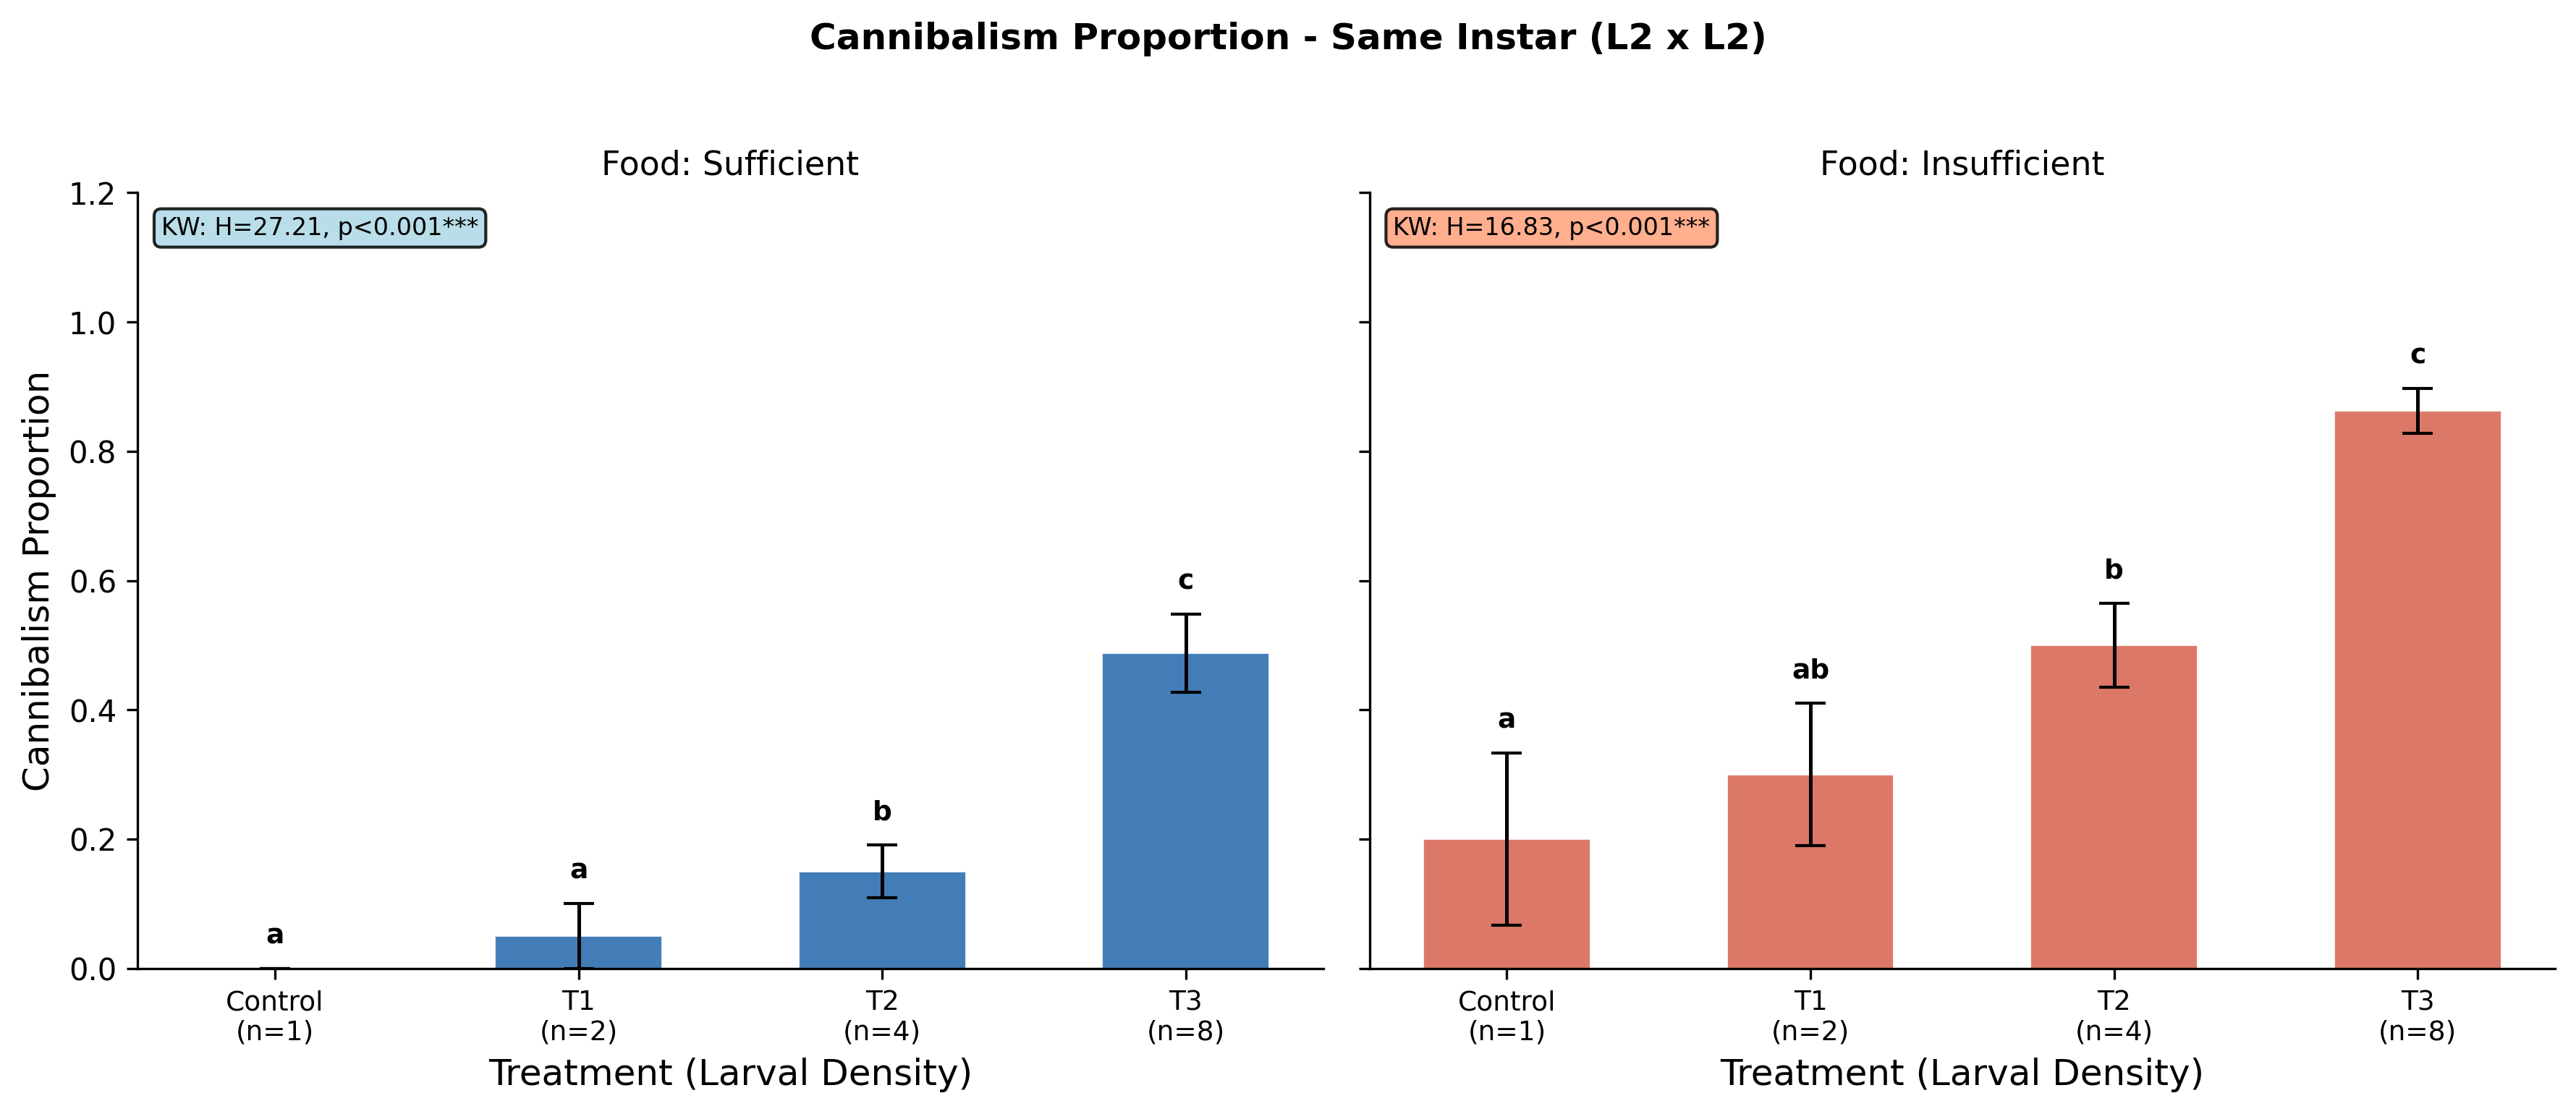

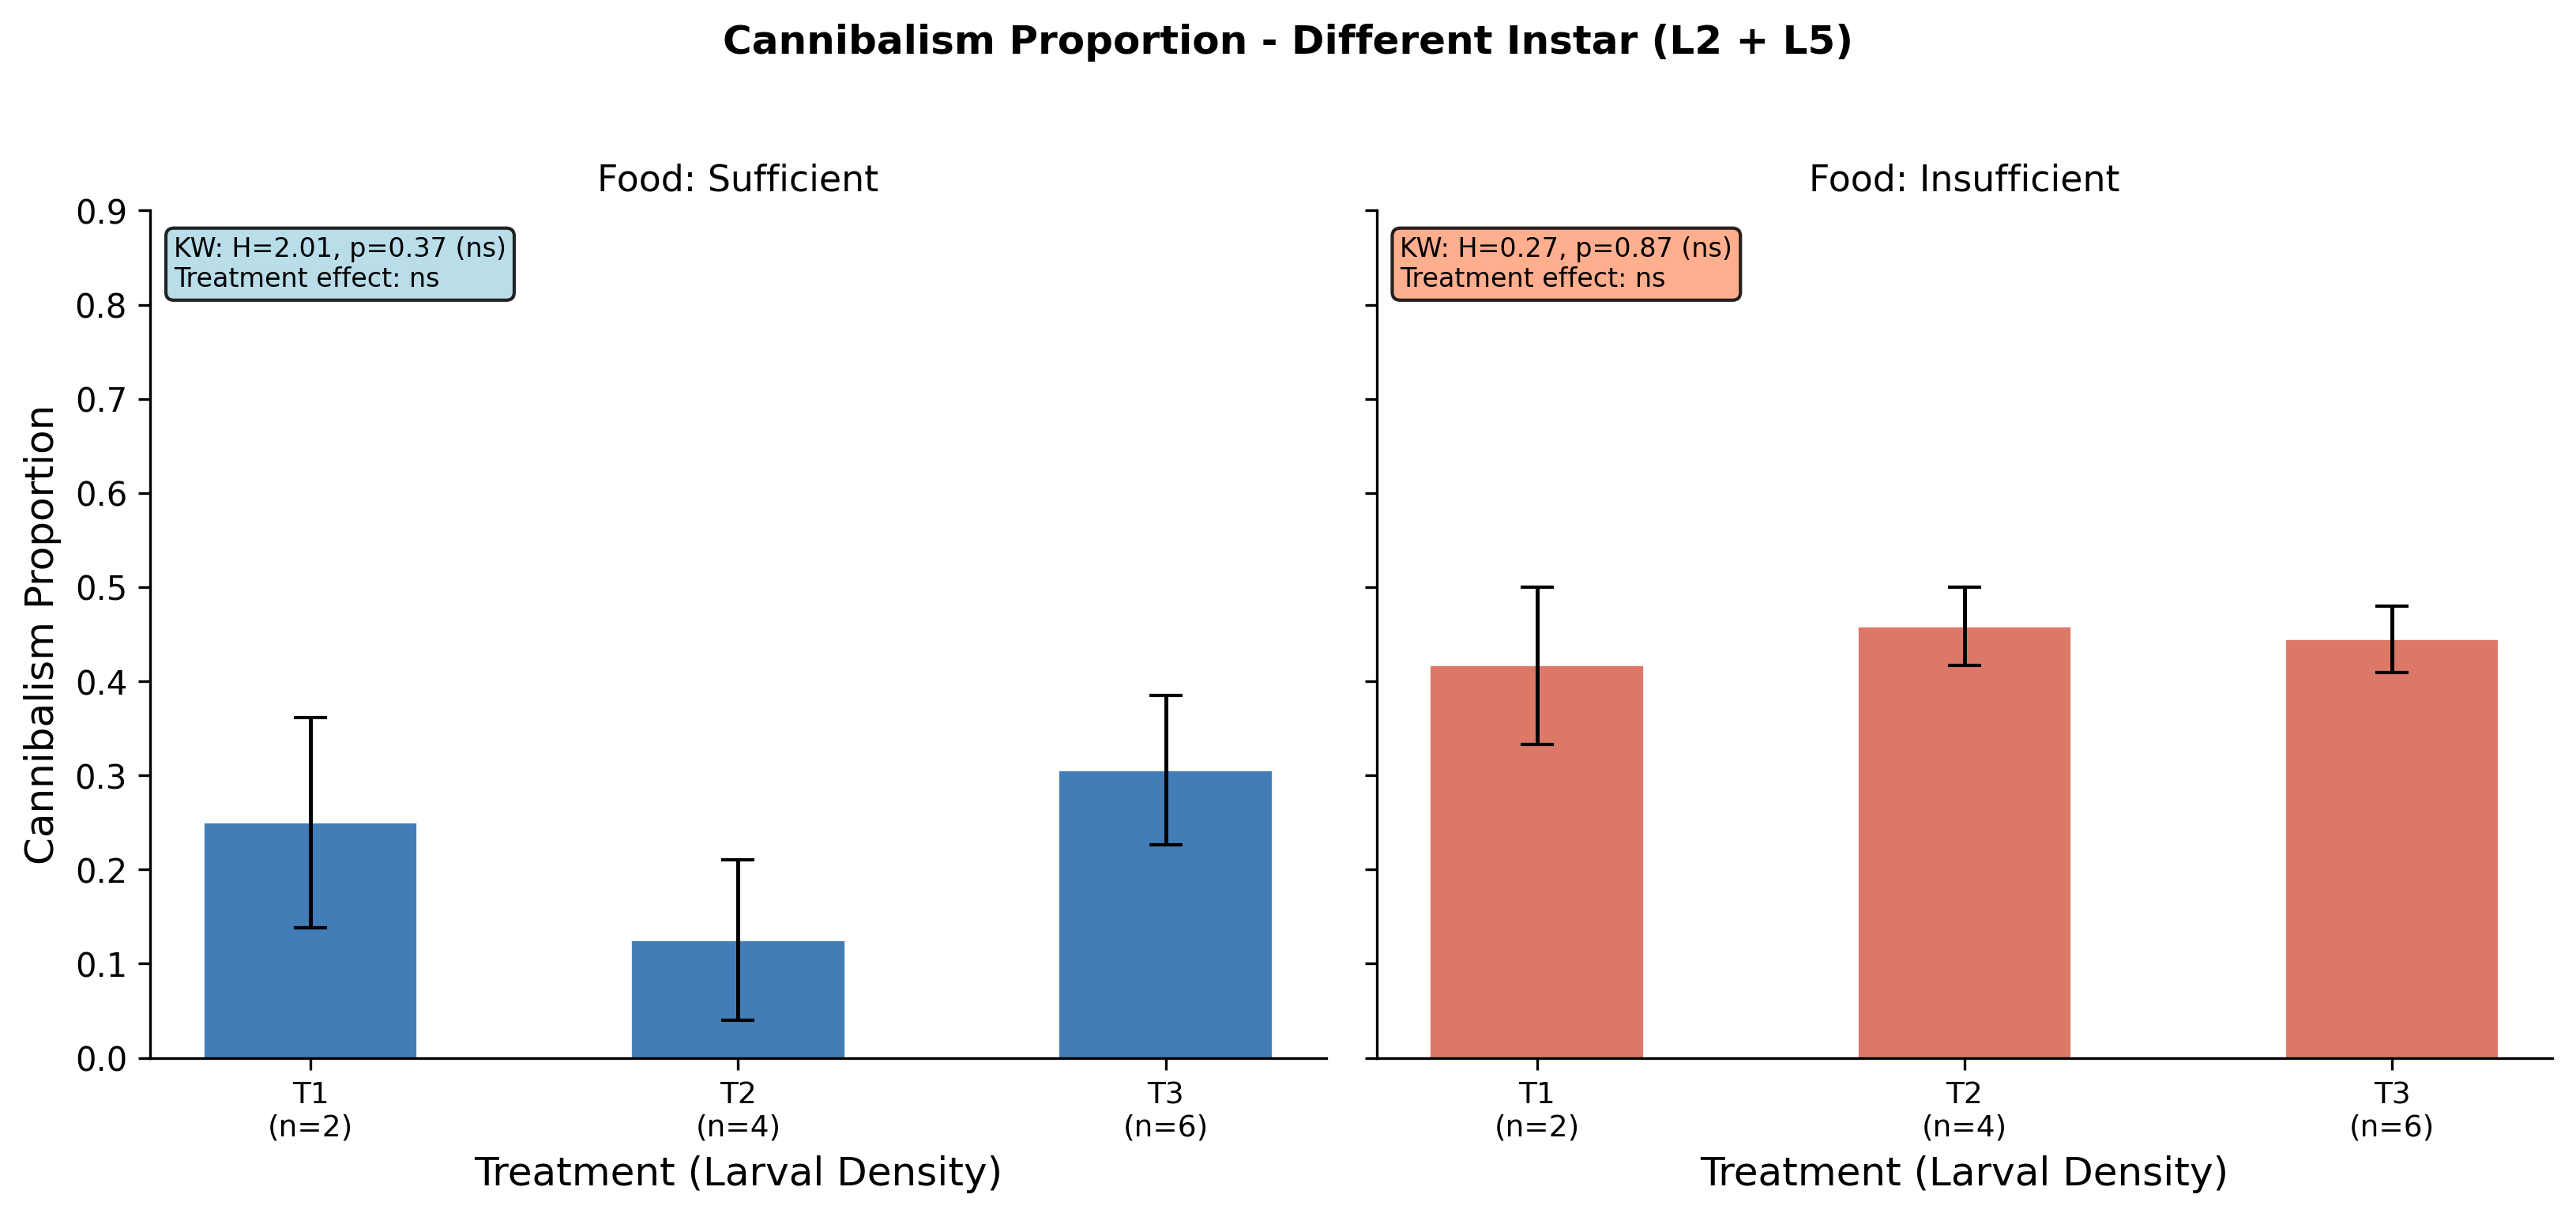

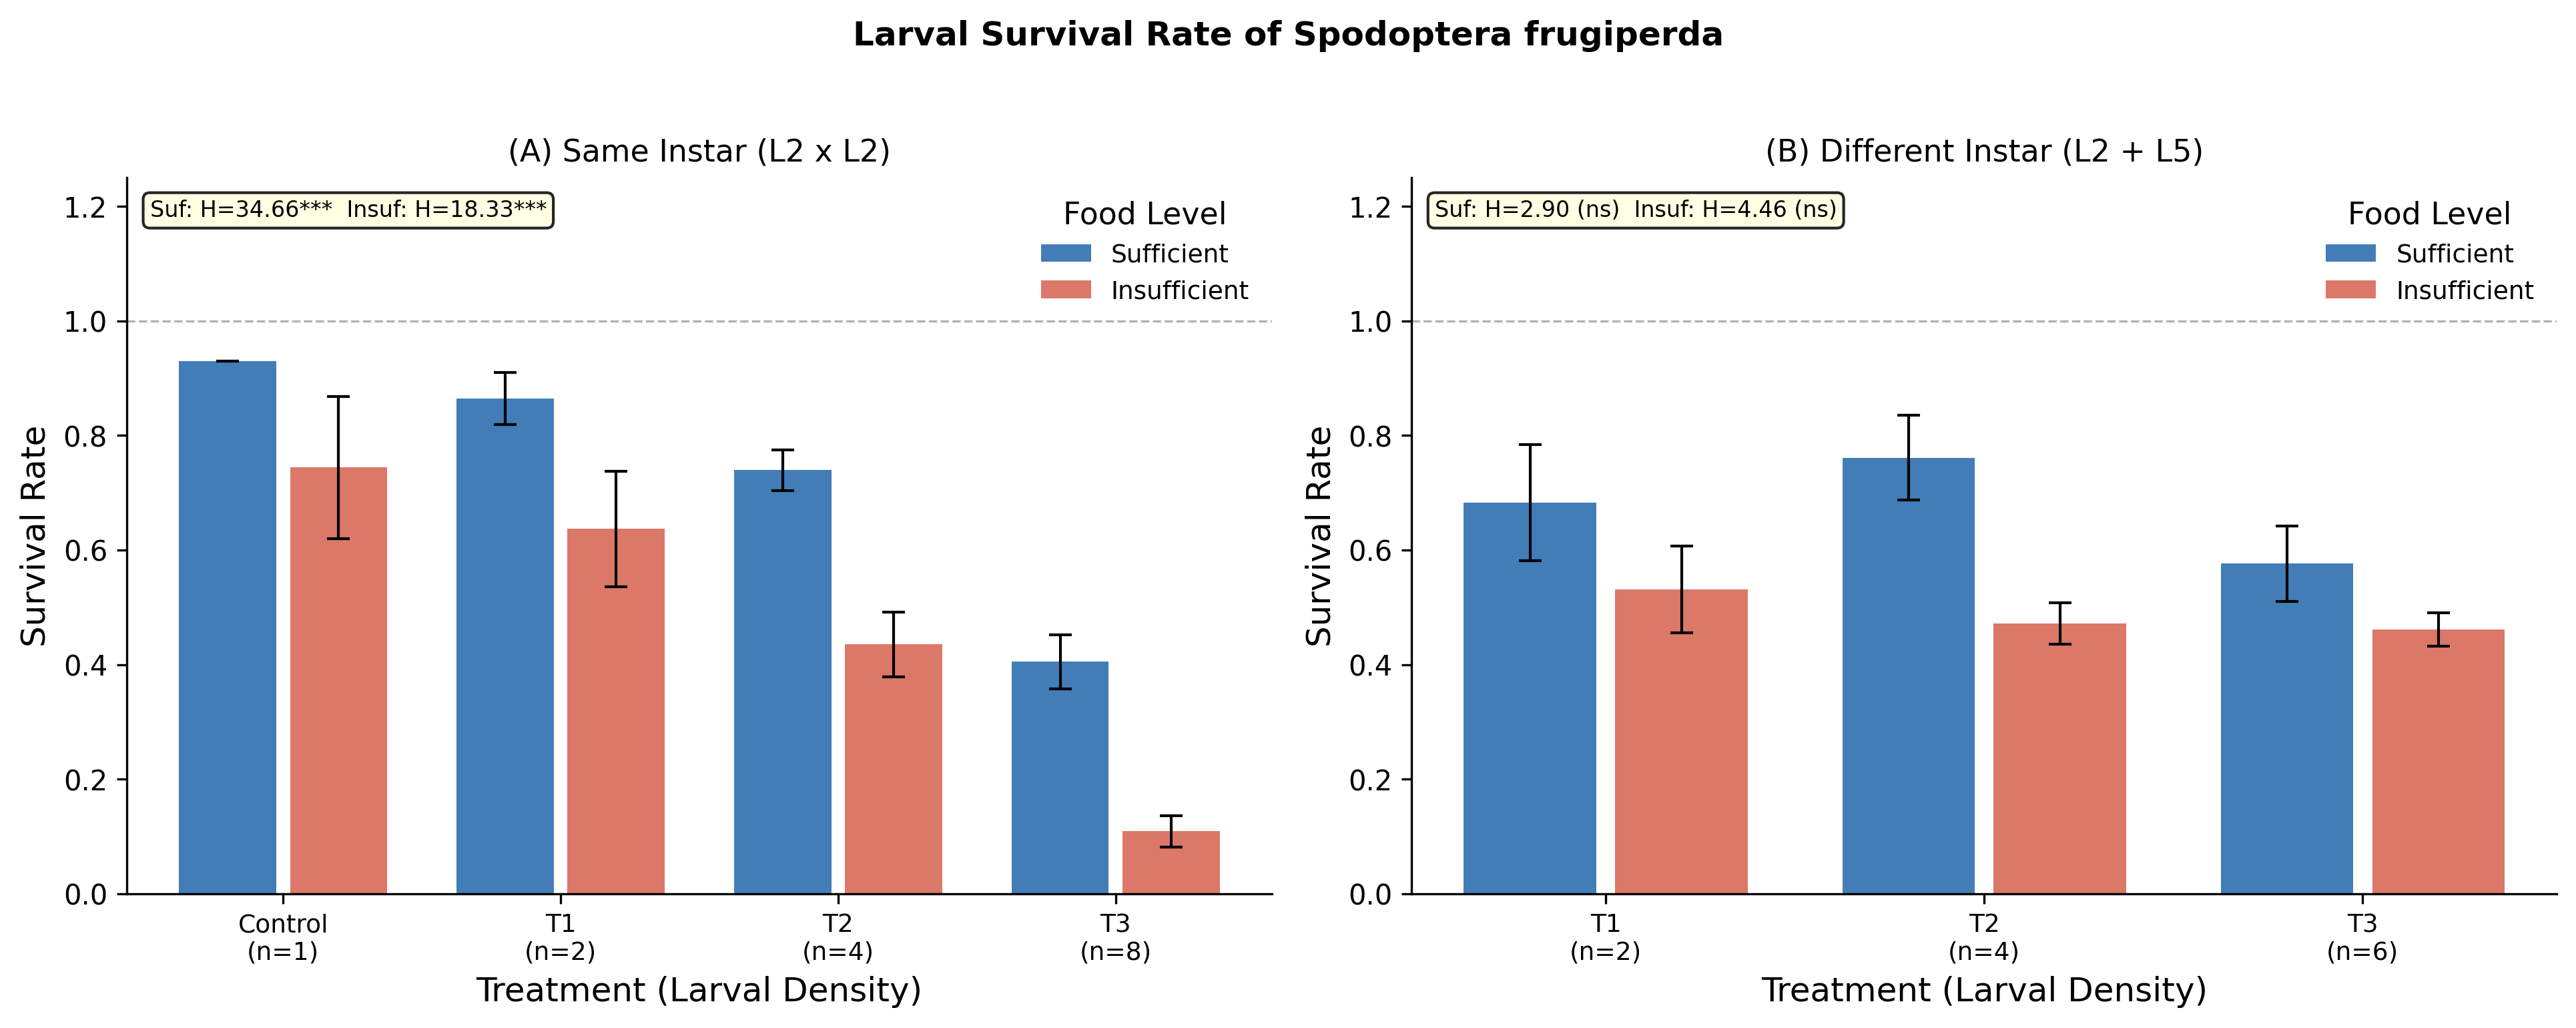

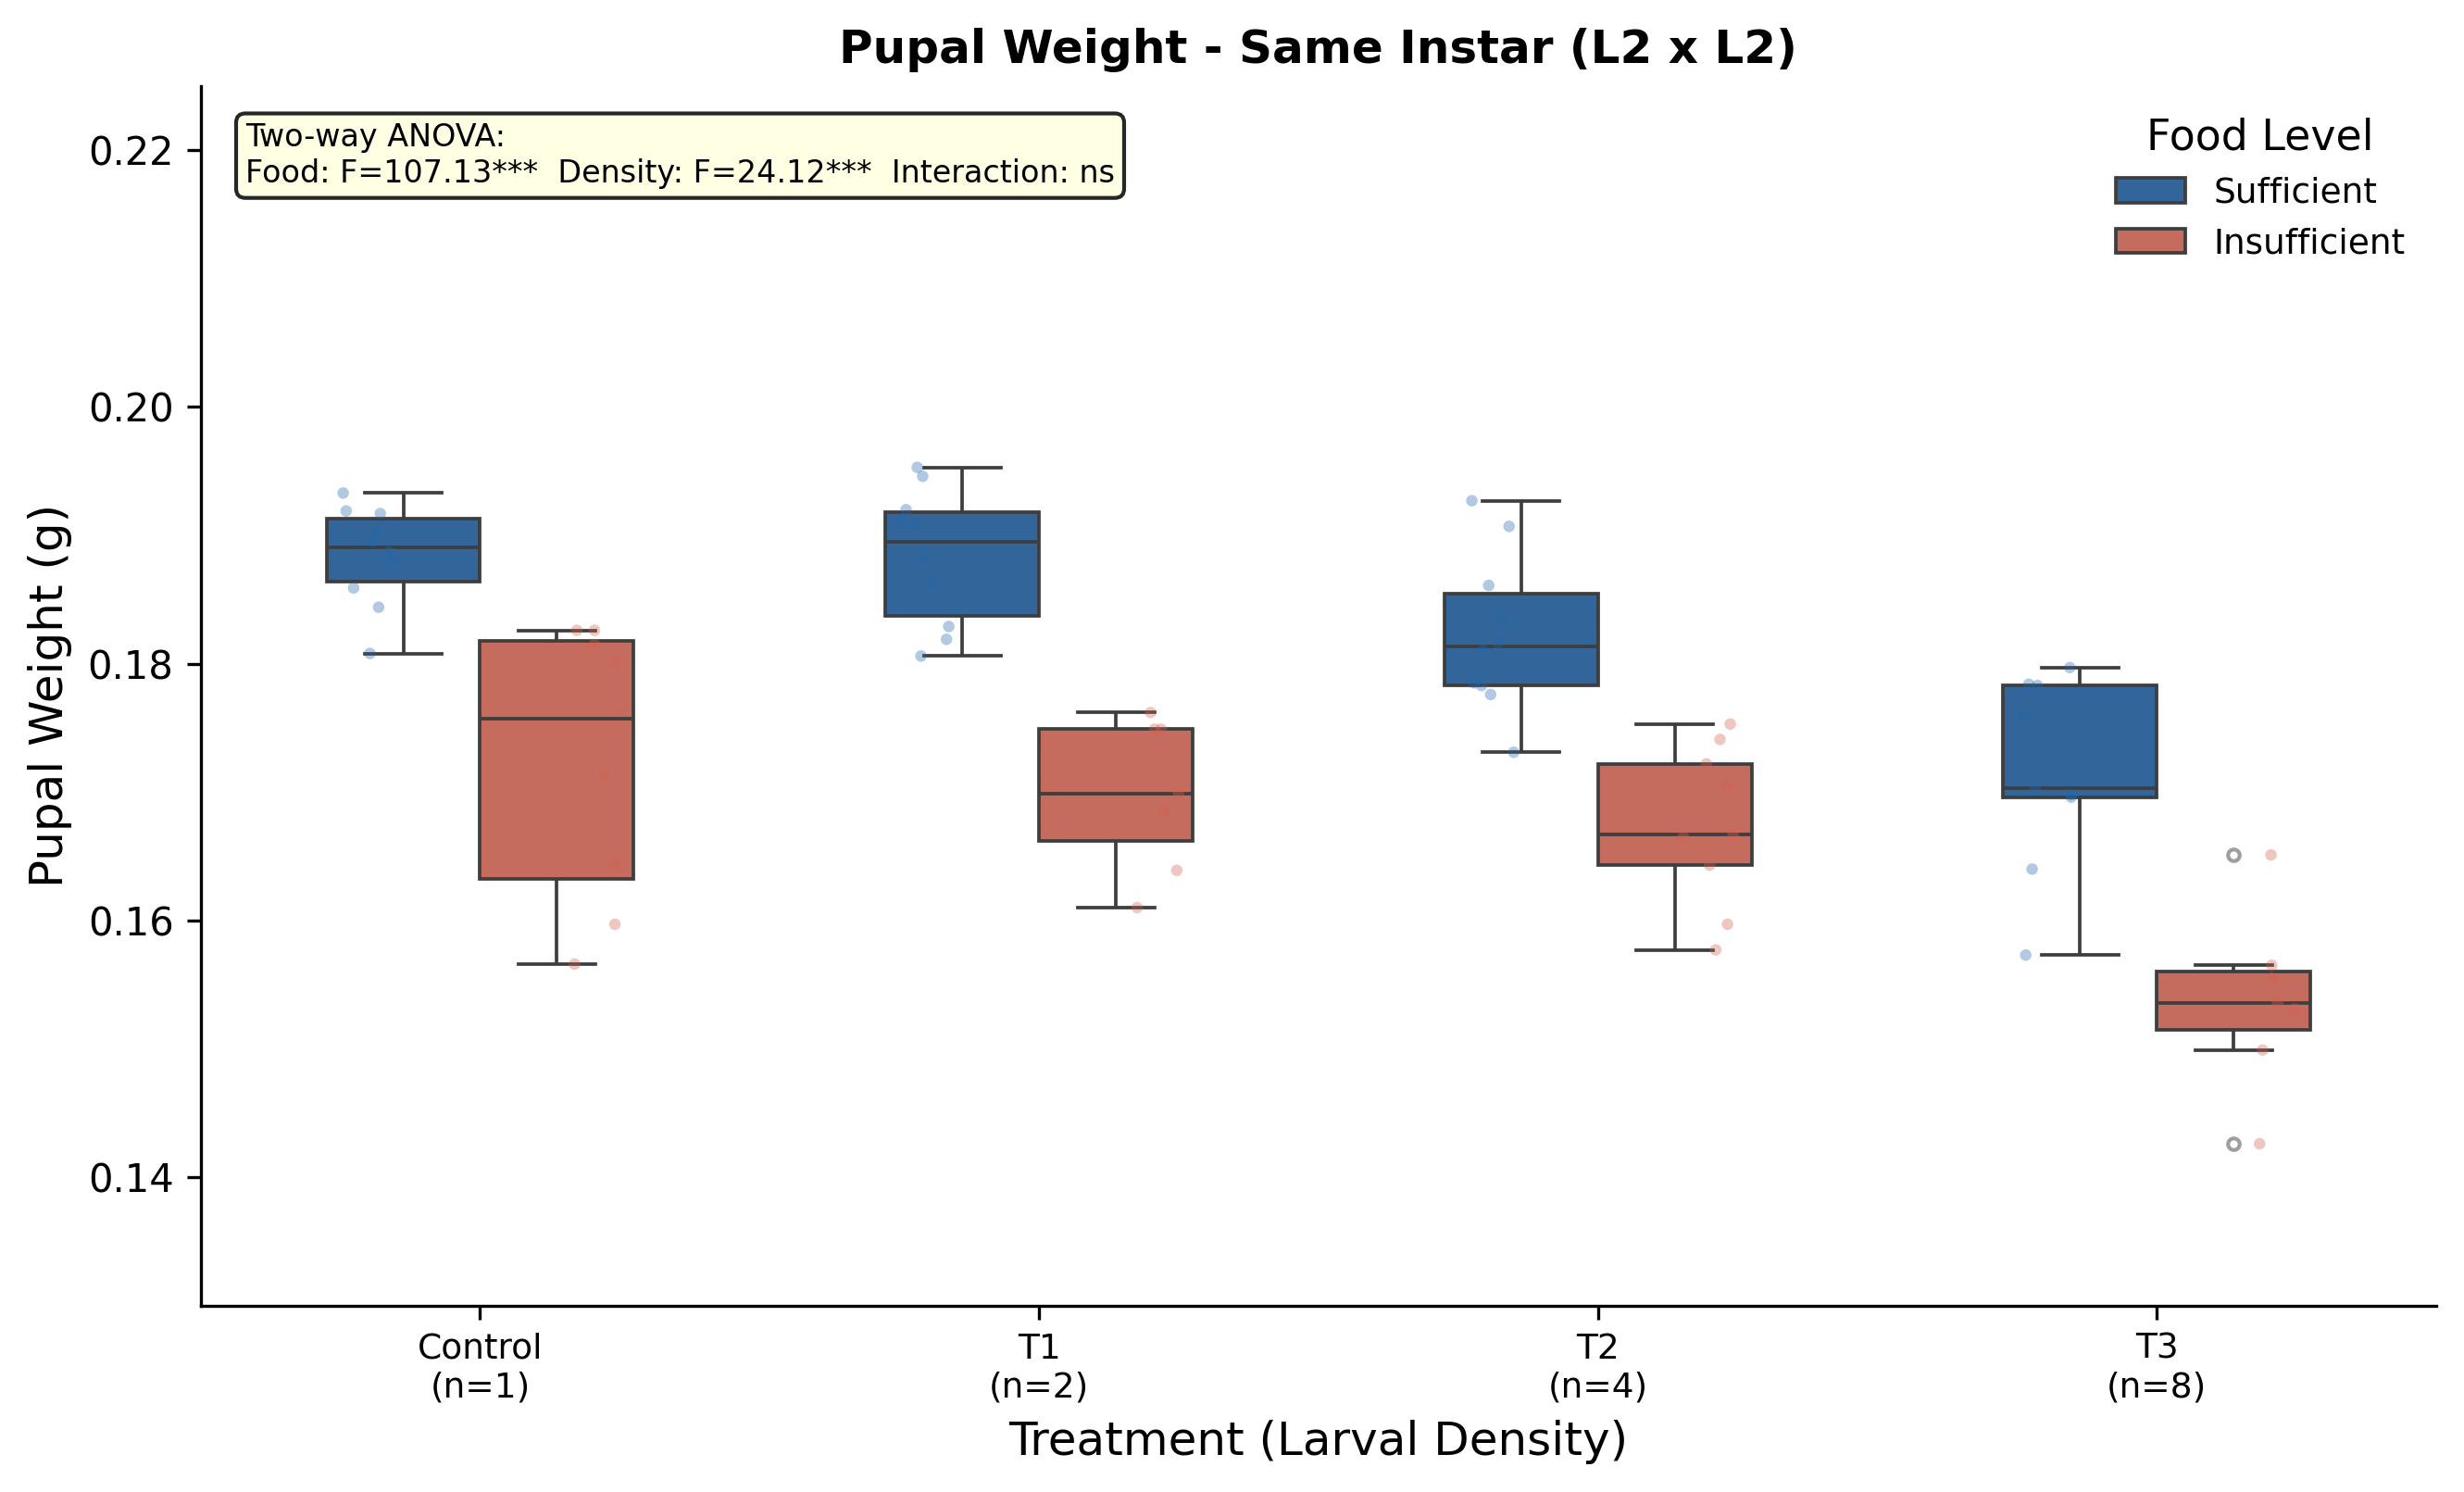

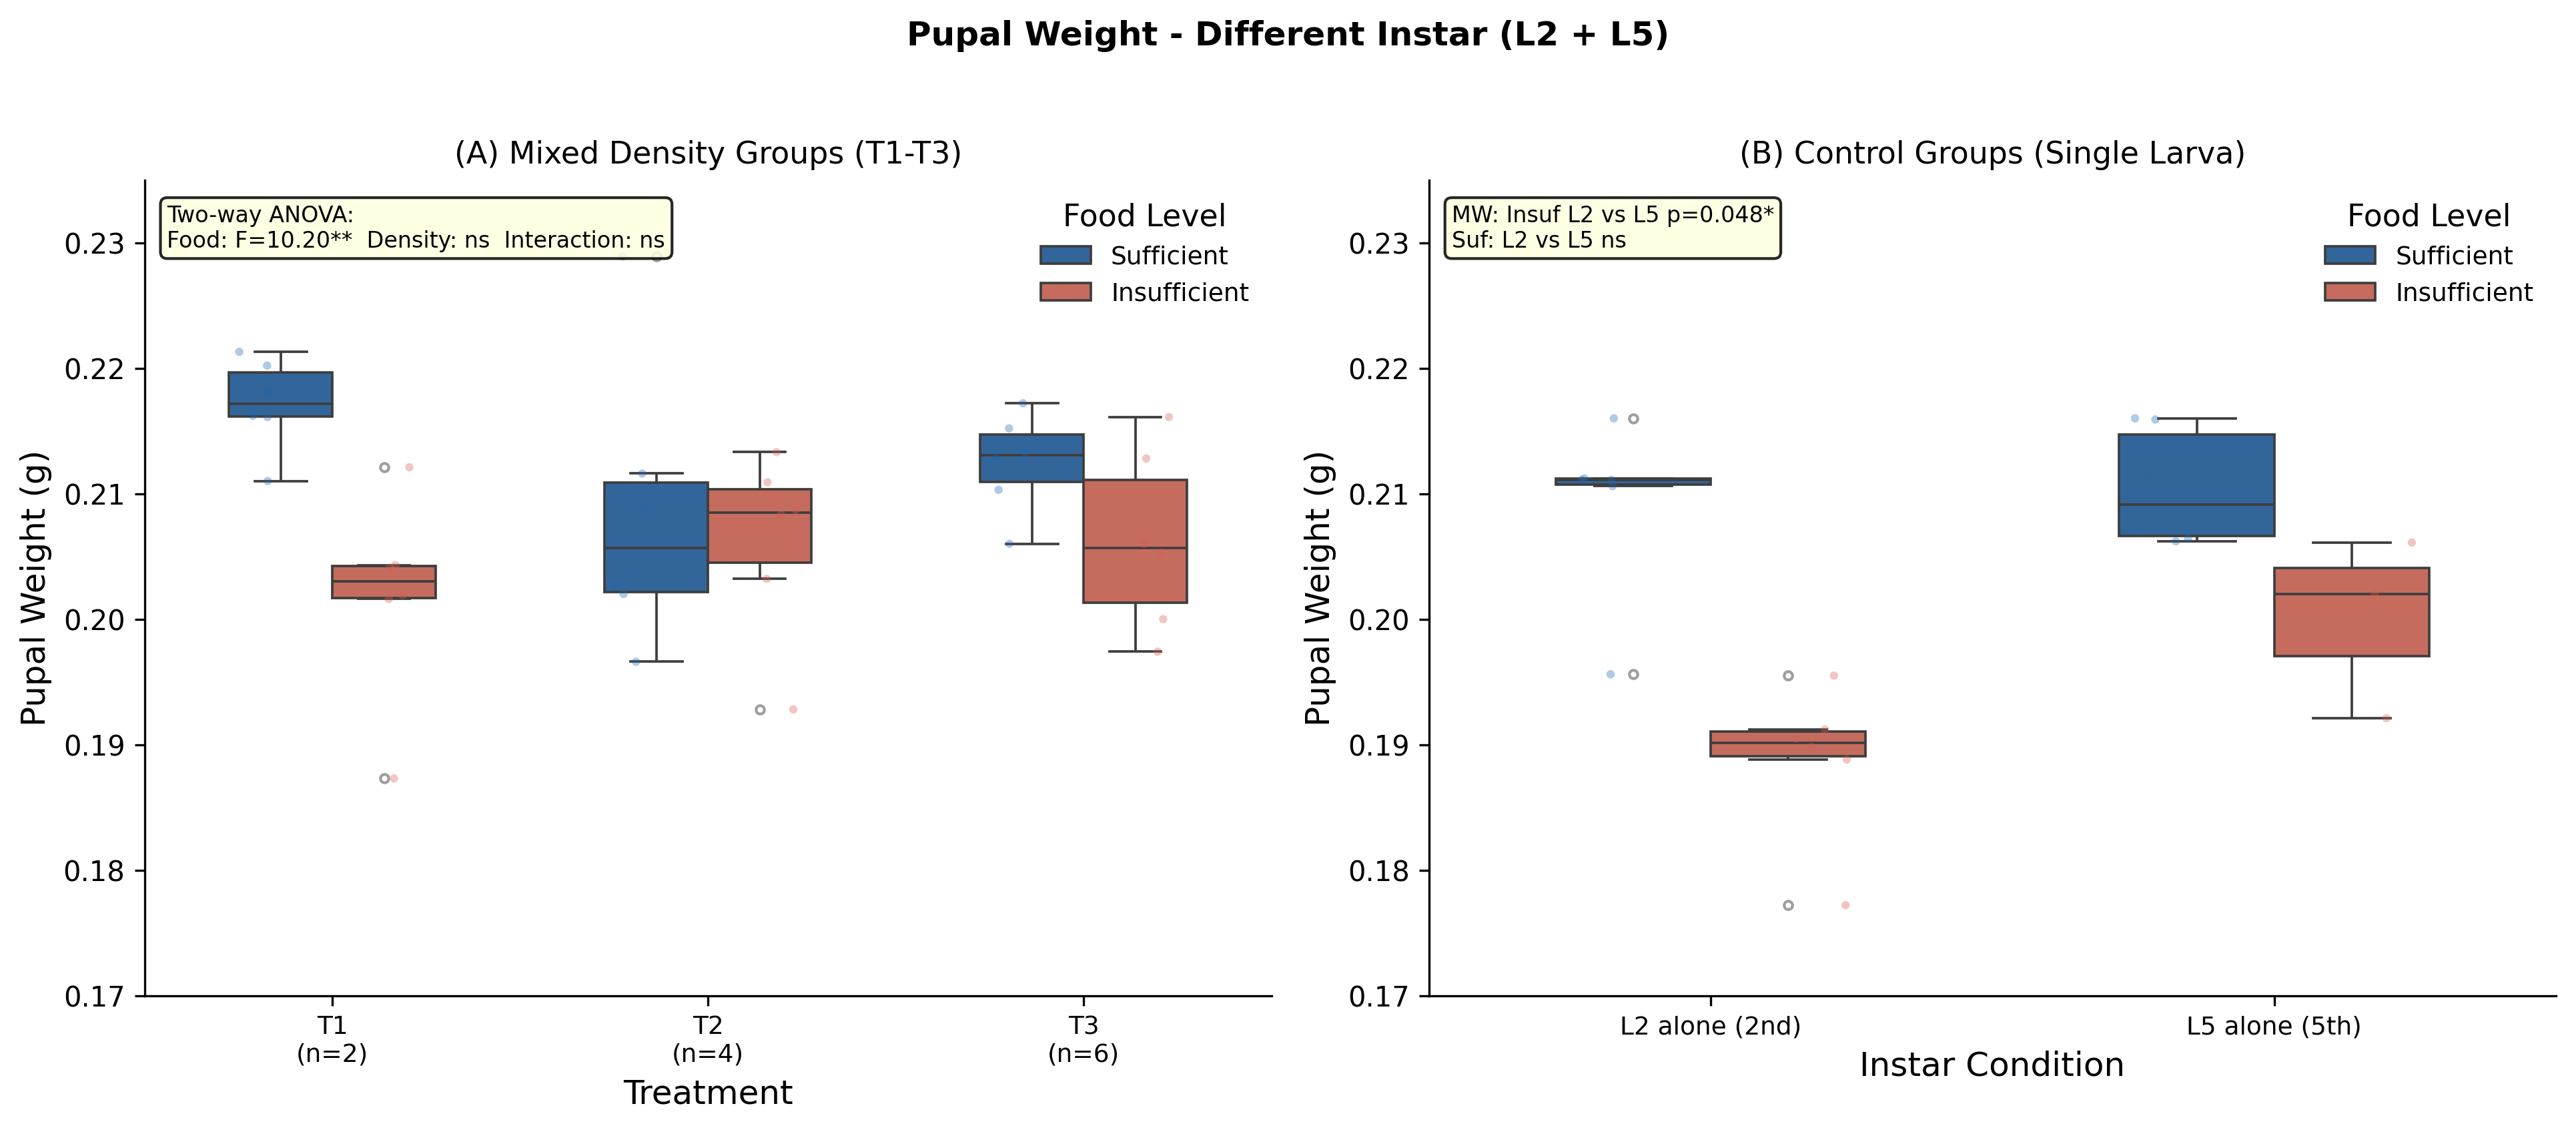

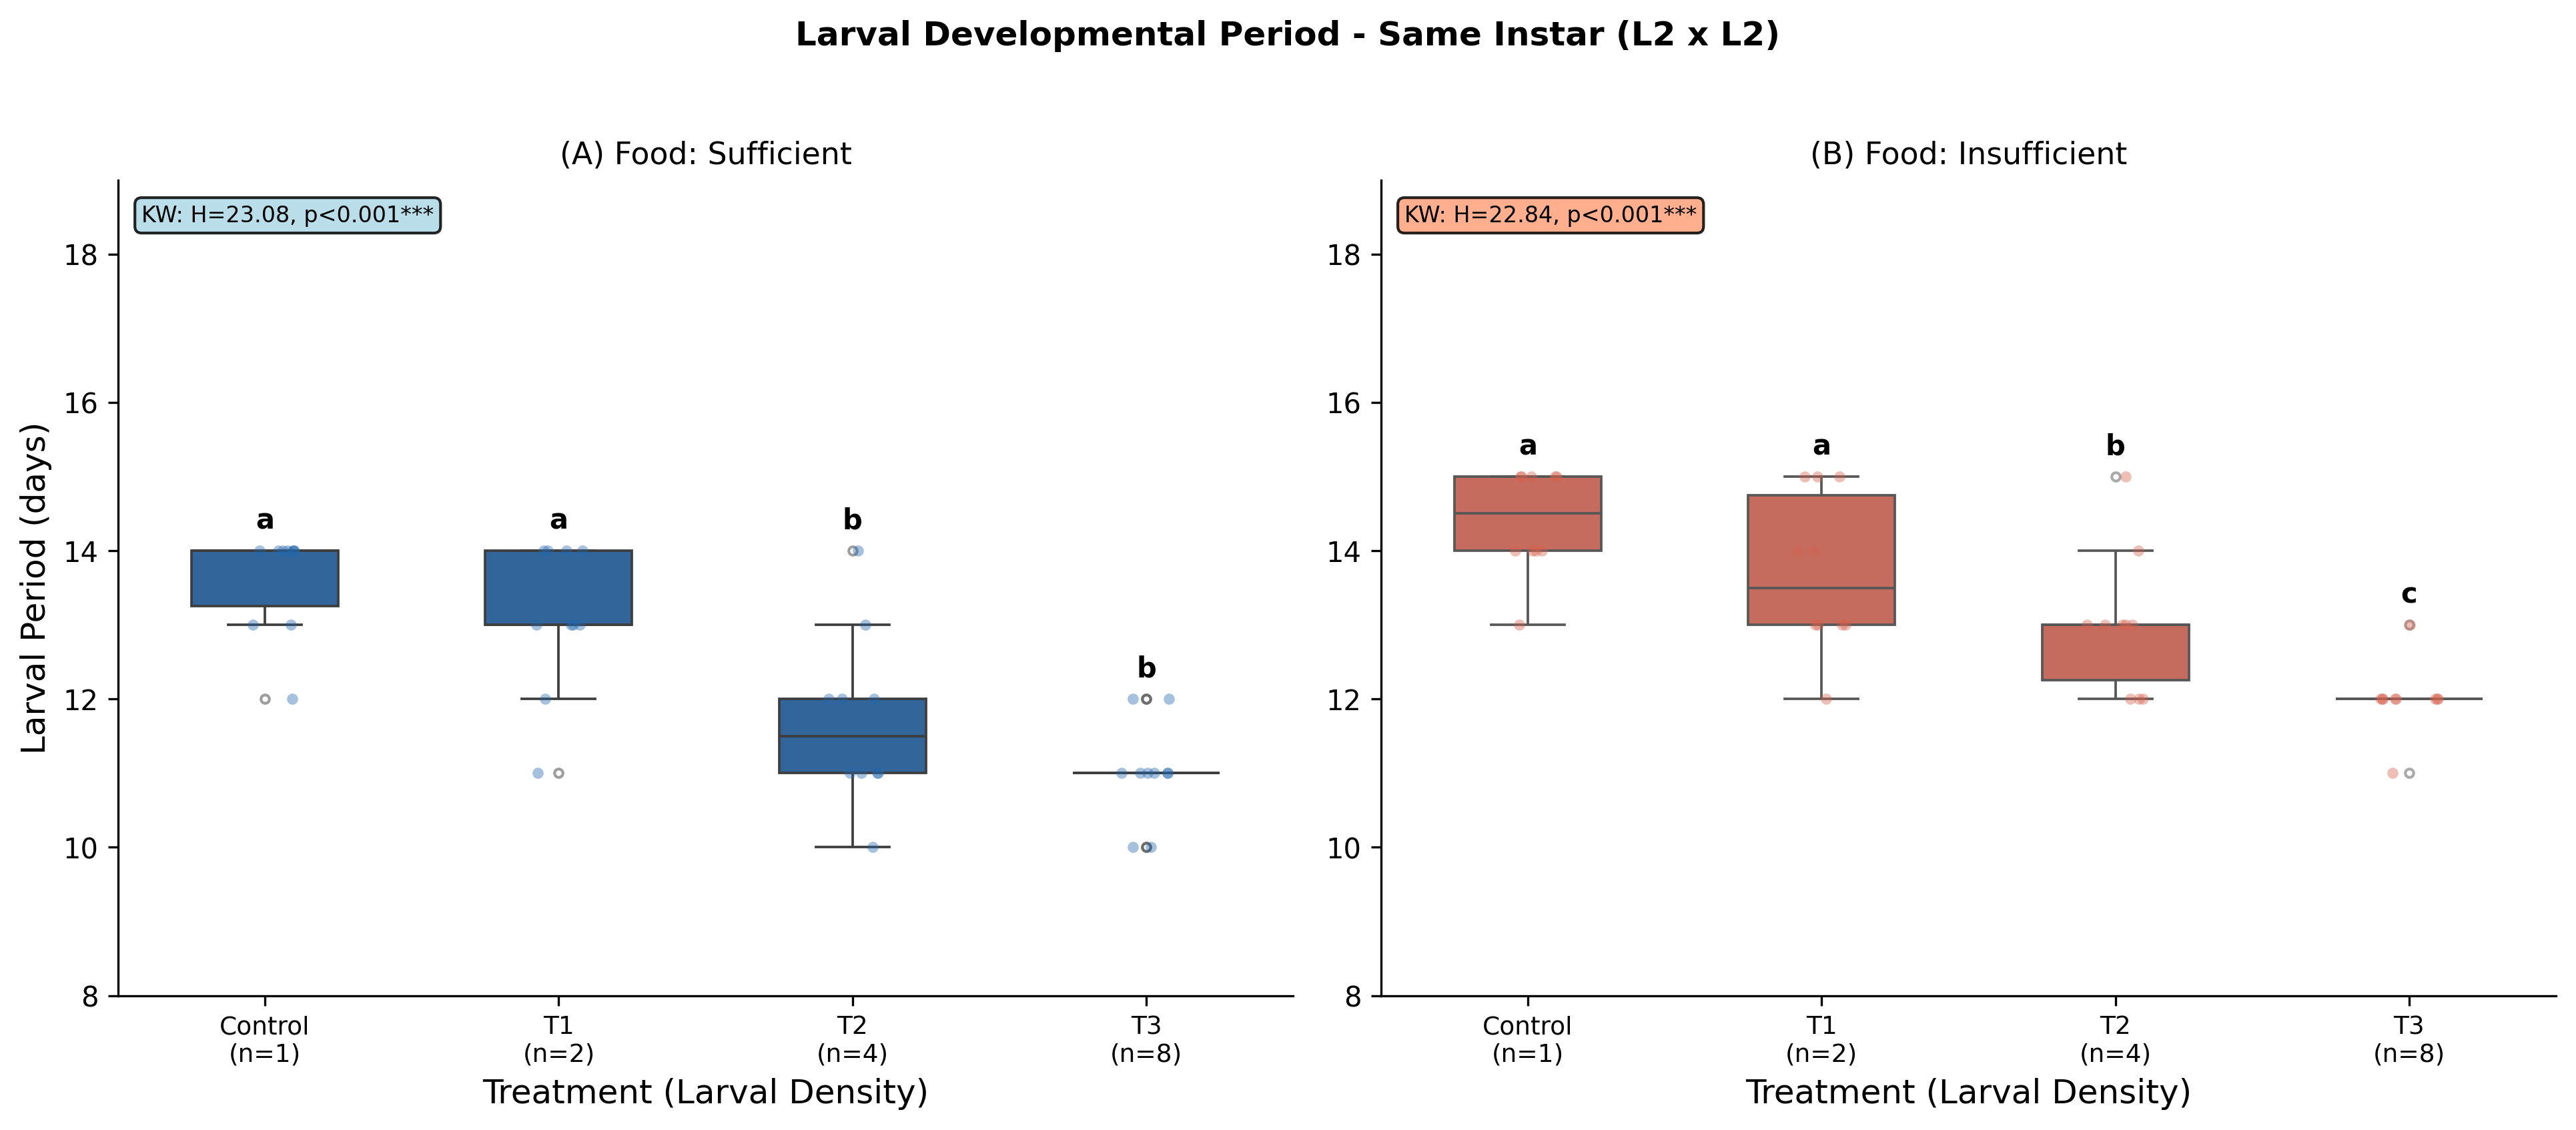

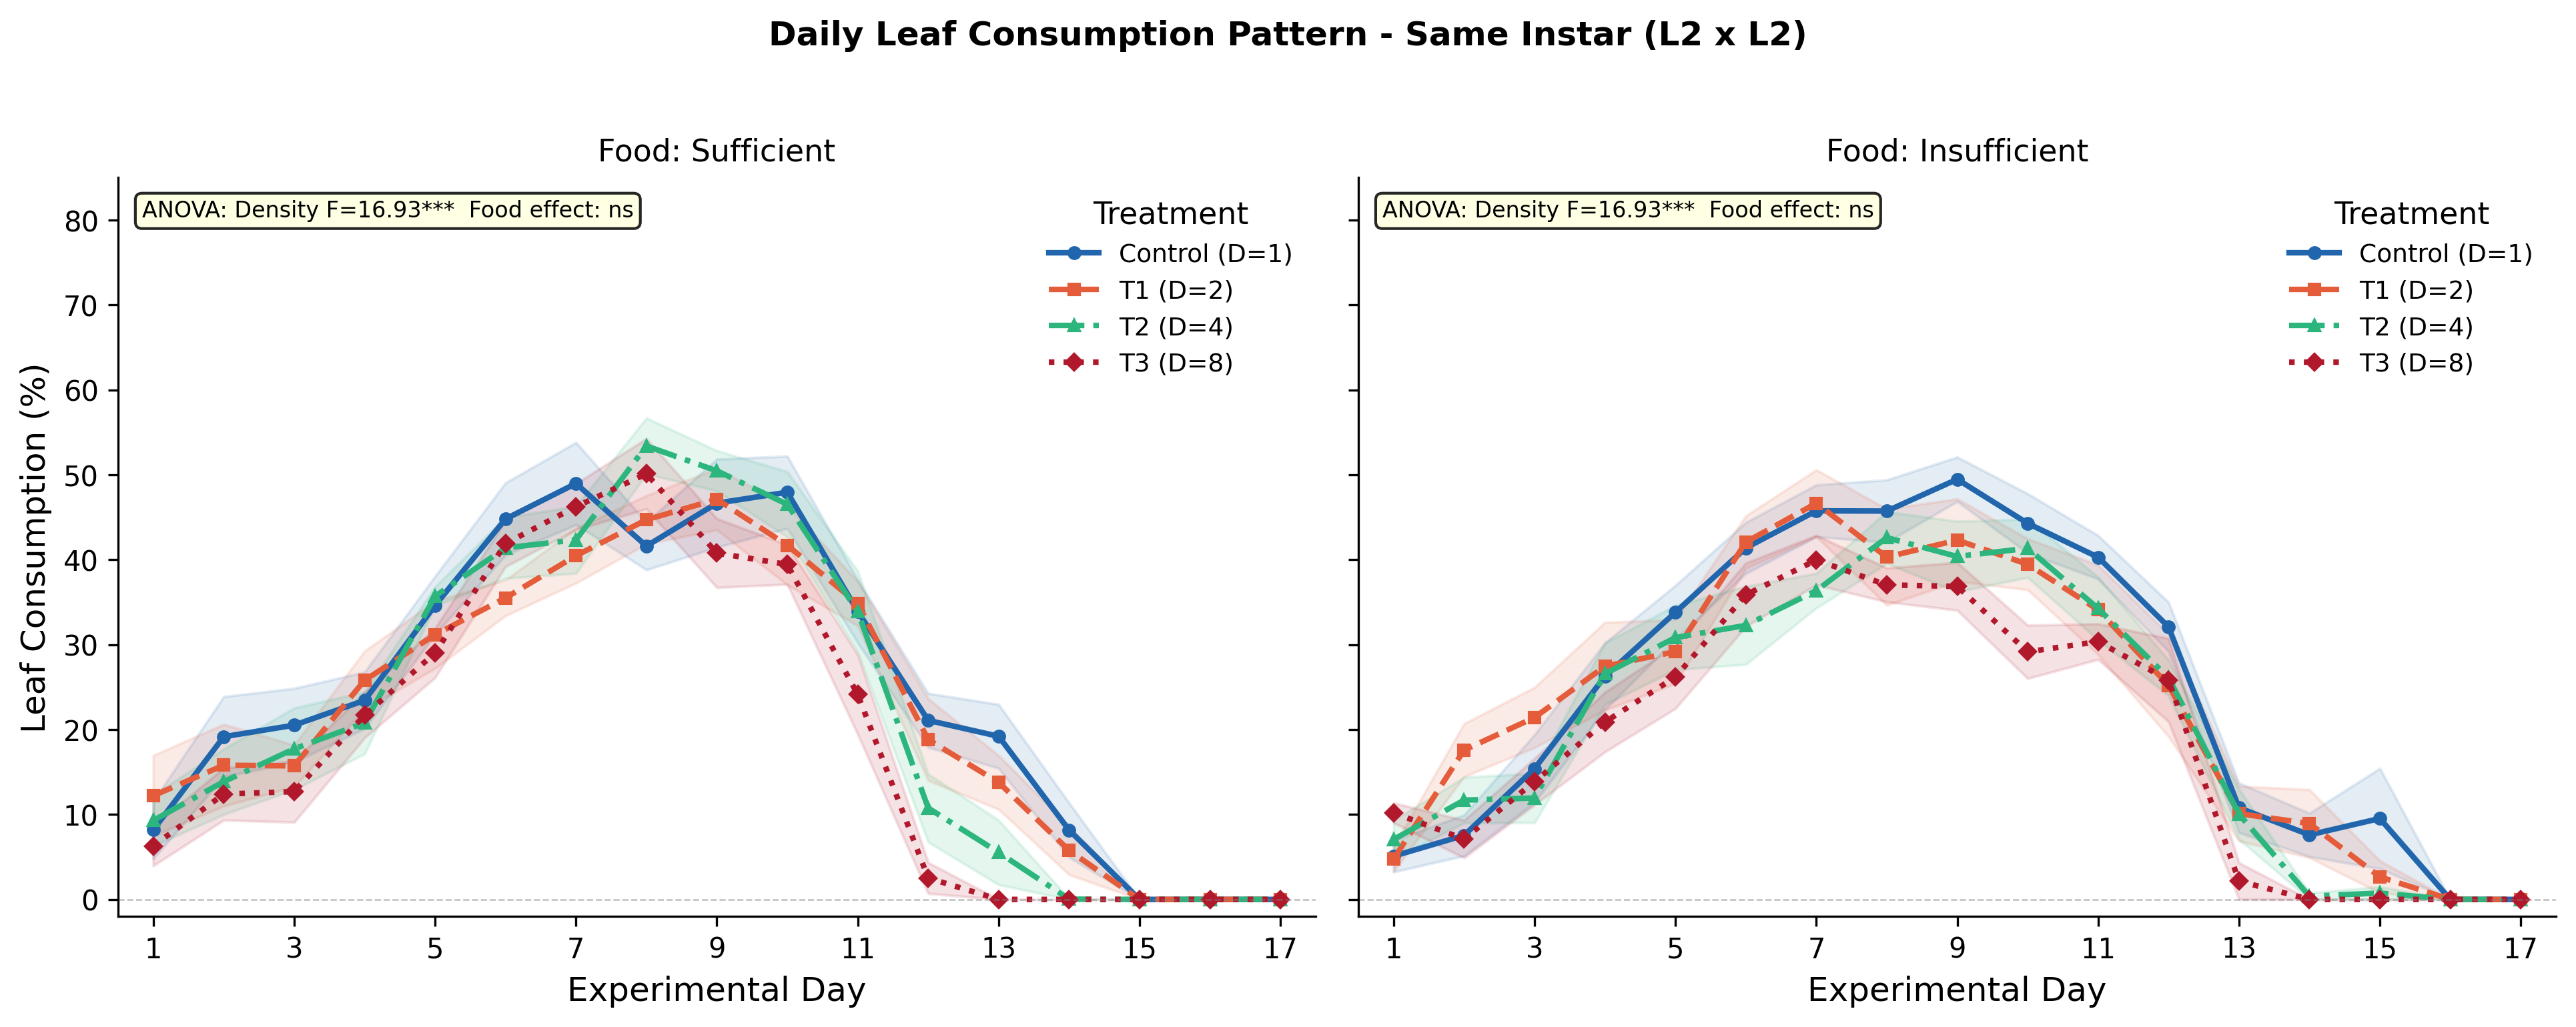

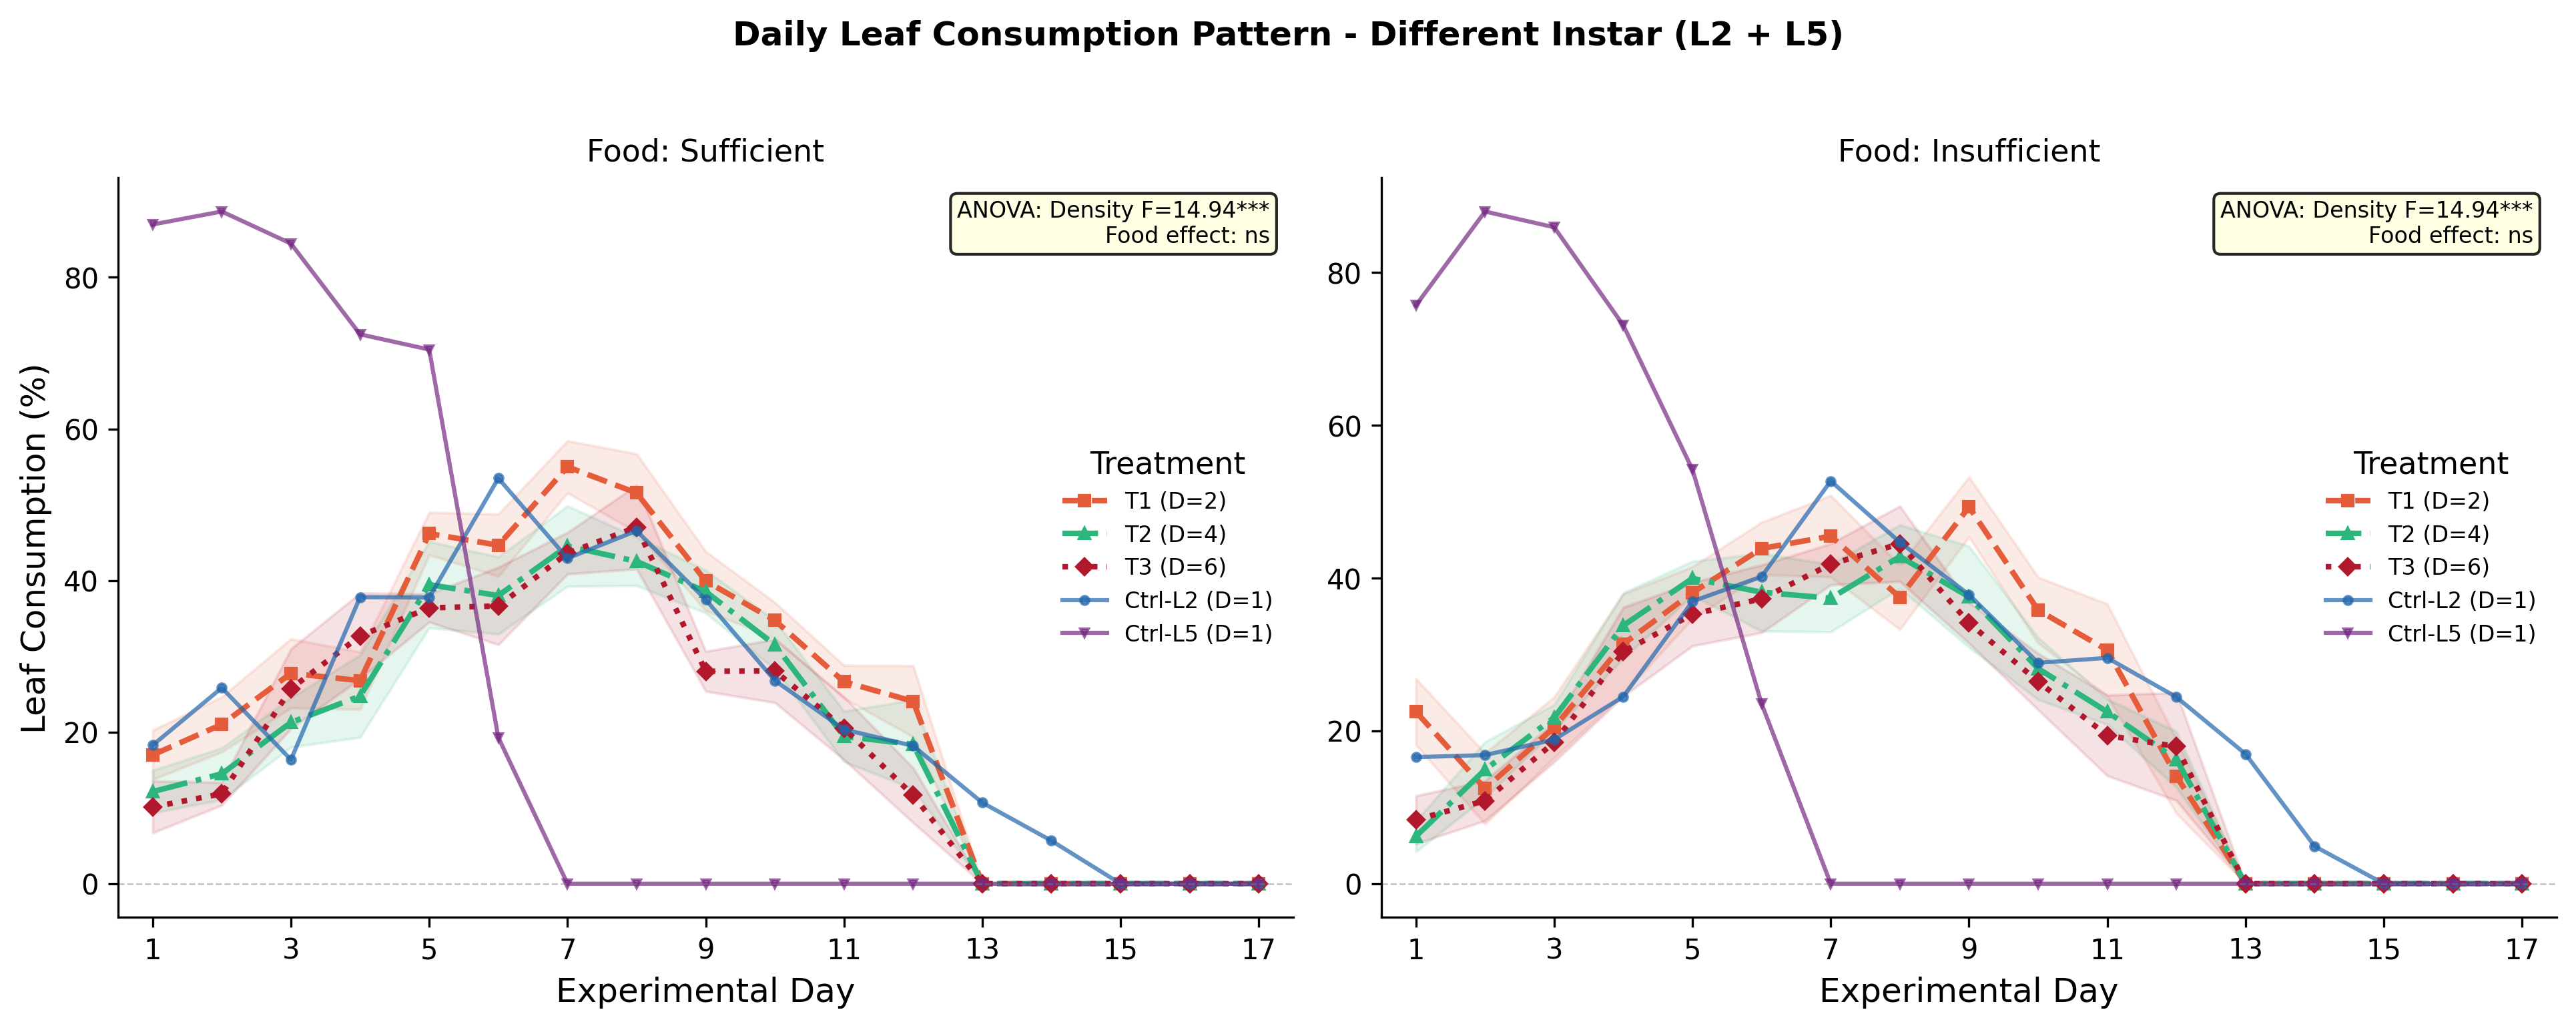

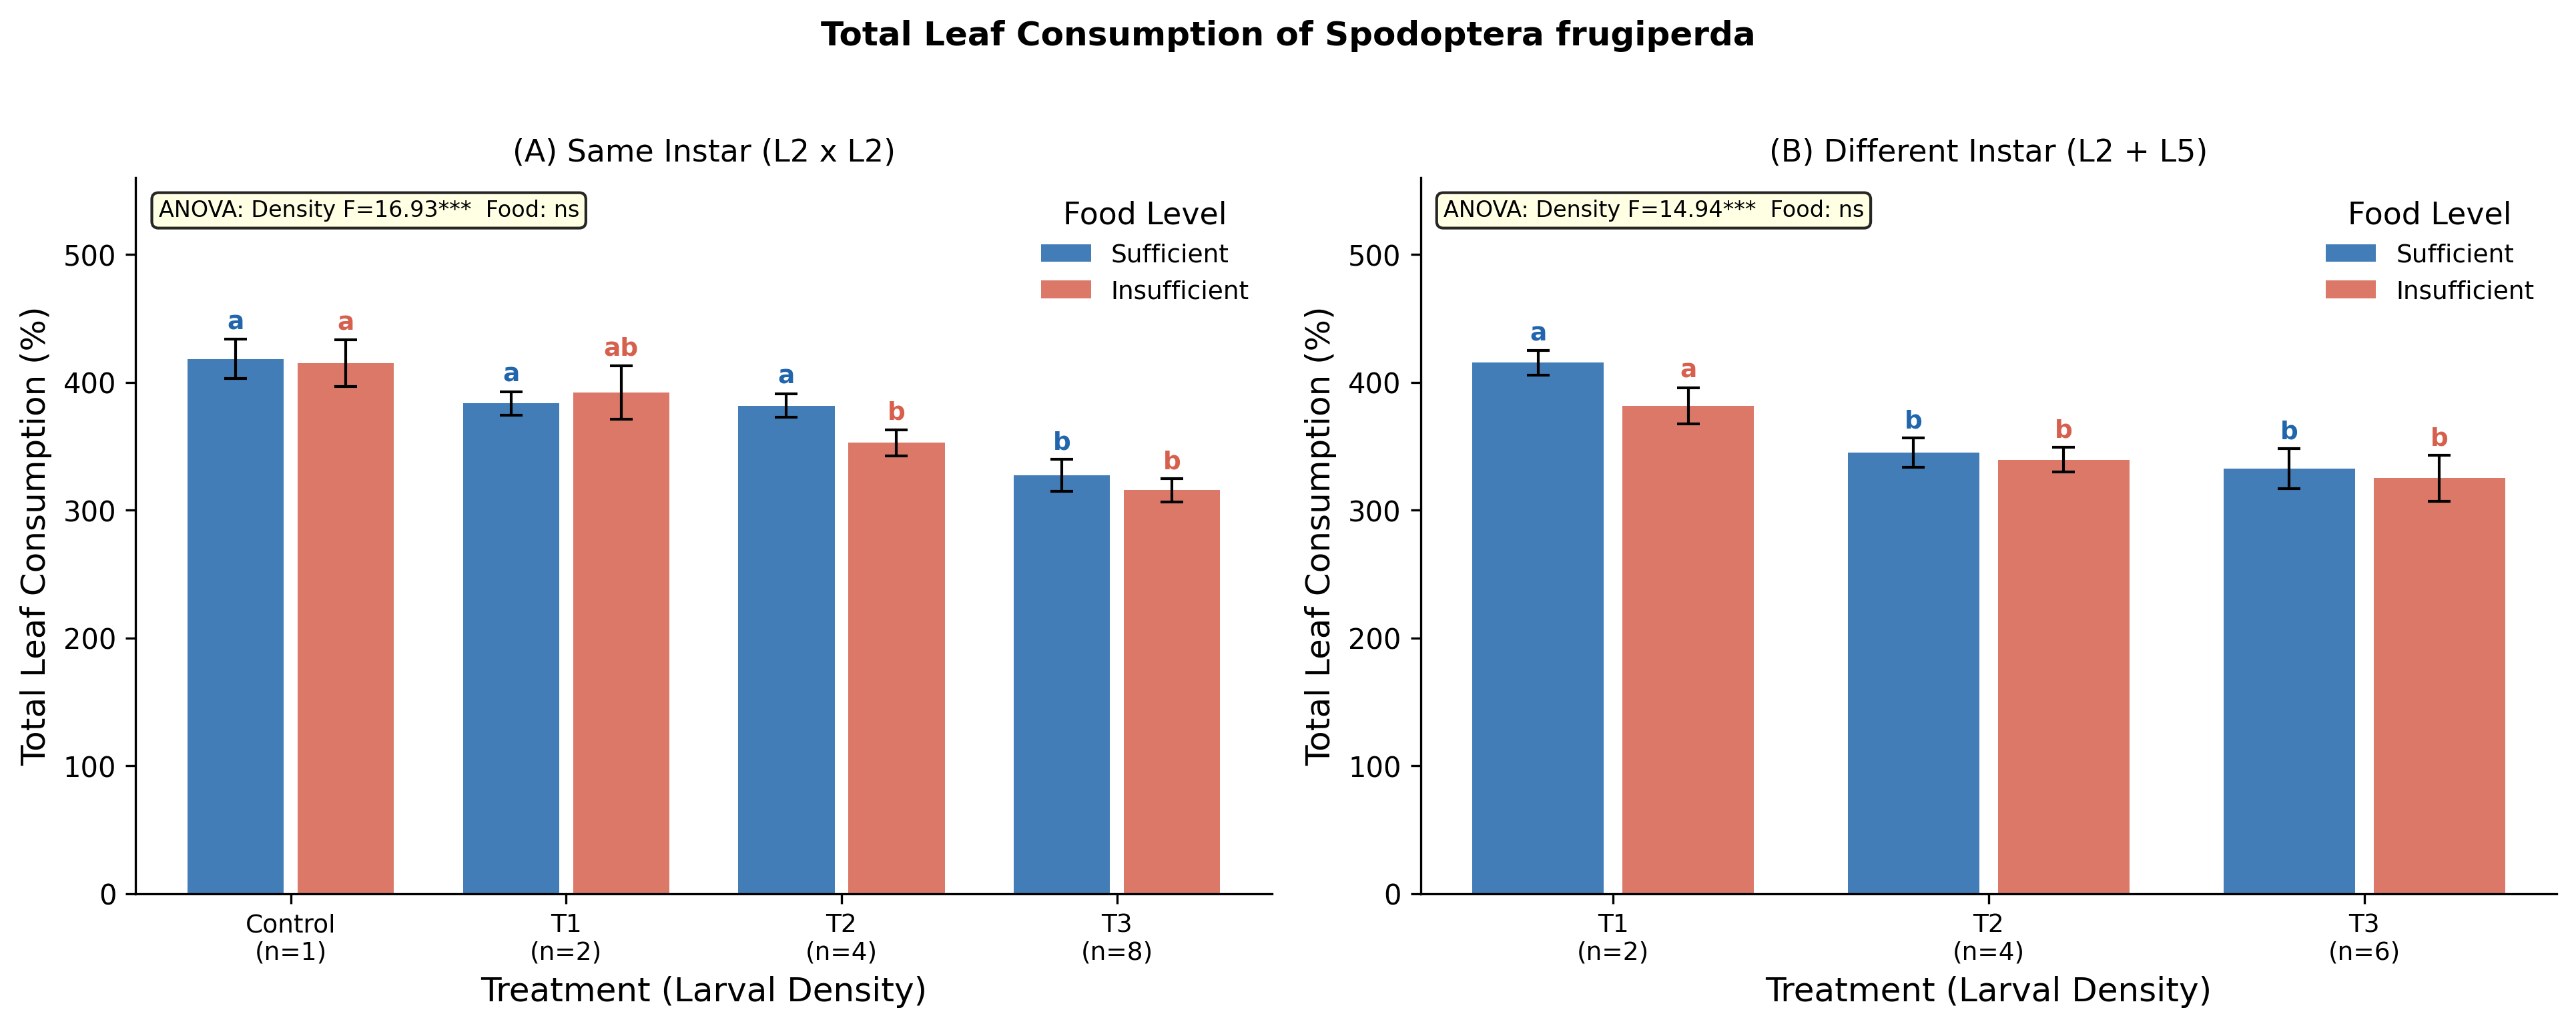

In [12]:
# STEP 5: Publication-Quality Figures
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

OUT_FIG    = '/content/drive/MyDrive/Data Analysis March 2026/Raina/Spodoptera frugiperda/Outputs/Figures'
TRT_ORDER  = ['Control', 'T1', 'T2', 'T3']
FOOD_ORDER = ['Sufficient', 'Insufficient']
COLOR_SUF   = '#2166AC'
COLOR_INSUF = '#D6604D'
COLORS_TRT  = ['#2166AC', '#E45C3A', '#2CB67D', '#B2182B']
DAY_COLS = ['Day' + str(i) for i in range(1, 18)]
DAYS     = list(range(1, 18))

plt.rcParams.update({
    'font.family'     : 'DejaVu Sans',
    'font.size'       : 11,
    'axes.labelsize'  : 12,
    'axes.titlesize'  : 12,
    'xtick.labelsize' : 10,
    'ytick.labelsize' : 10,
    'legend.fontsize' : 10,
    'figure.dpi'      : 300,
    'savefig.dpi'     : 300,
    'savefig.bbox'    : 'tight',
    'axes.spines.top' : False,
    'axes.spines.right': False,
    'axes.linewidth'  : 0.8,
})

def annotate_letters(ax, x_pos, letters, y_vals, offset=0.02, color='black'):
    for x, letter, y in zip(x_pos, letters, y_vals):
        ax.text(x, y + offset, letter, ha='center', va='bottom', fontsize=9, fontweight='bold', color=color)

def stat_box(ax, text, fc='lightyellow'):
    ax.text(0.02, 0.97, text, transform=ax.transAxes, fontsize=8, va='top',
            bbox=dict(boxstyle='round,pad=0.3', facecolor=fc, alpha=0.85))

# ============================================================
# FIGURE 1: CANNIBALISM PROPORTION - SAME INSTAR
# ============================================================
sig_cb = {'Sufficient': {'Control':'a','T1':'a','T2':'b','T3':'c'},
          'Insufficient': {'Control':'a','T1':'ab','T2':'b','T3':'c'}}
xtick_same = ['Control\n(n=1)', 'T1\n(n=2)', 'T2\n(n=4)', 'T3\n(n=8)']
x4 = np.arange(4)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
fig.suptitle('Cannibalism Proportion - Same Instar (L2 x L2)', fontsize=12, fontweight='bold', y=1.02)
for ax, food, color in zip(axes, FOOD_ORDER, [COLOR_SUF, COLOR_INSUF]):
    grp   = cb_same[cb_same['Food_Condition']==food].groupby('Treatment')['Cannibalism_Prop']
    means = grp.mean().reindex(TRT_ORDER)
    sems  = grp.sem().reindex(TRT_ORDER)
    ax.bar(x4, means, width=0.55, color=color, alpha=0.85,
           yerr=sems, capsize=5, error_kw=dict(elinewidth=1.2, ecolor='black'),
           edgecolor='white', linewidth=0.5)
    letters = [sig_cb[food][t] for t in TRT_ORDER]
    annotate_letters(ax, x4, letters, means.values + sems.values, offset=0.03)
    ax.set_title('Food: ' + food, fontsize=11)
    ax.set_xlabel('Treatment (Larval Density)', fontsize=12)
    ax.set_ylabel('Cannibalism Proportion' if food=='Sufficient' else '', fontsize=12)
    ax.set_xticks(x4)
    ax.set_xticklabels(xtick_same, fontsize=9)
    ax.set_ylim(0, 1.2)
    kw = 'KW: H=27.21, p<0.001***' if food=='Sufficient' else 'KW: H=16.83, p<0.001***'
    fc = 'lightblue' if food=='Sufficient' else 'lightsalmon'
    stat_box(ax, kw, fc)
plt.tight_layout()
path1 = OUT_FIG + '/Figure1_Cannibalism_Same_Instar.png'
plt.savefig(path1, dpi=300, bbox_inches='tight')
print('Saved: ' + path1)

# ============================================================
# FIGURE 2: CANNIBALISM PROPORTION - DIFFERENT INSTAR
# ============================================================
trt3  = ['T1','T2','T3']
x3    = np.arange(3)
xtick3 = ['T1\n(n=2)', 'T2\n(n=4)', 'T3\n(n=6)']
cb_diff_m = cb_diff[cb_diff['Instar_Condition']=='Different']

fig, axes = plt.subplots(1, 2, figsize=(11, 5), sharey=True)
fig.suptitle('Cannibalism Proportion - Different Instar (L2 + L5)', fontsize=12, fontweight='bold', y=1.02)
for ax, food, color in zip(axes, FOOD_ORDER, [COLOR_SUF, COLOR_INSUF]):
    grp   = cb_diff_m[cb_diff_m['Food_Condition']==food].groupby('Treatment')['Cannibalism_Prop']
    means = grp.mean().reindex(trt3)
    sems  = grp.sem().reindex(trt3)
    ax.bar(x3, means, width=0.5, color=color, alpha=0.85,
           yerr=sems, capsize=5, error_kw=dict(elinewidth=1.2, ecolor='black'),
           edgecolor='white', linewidth=0.5)
    ax.set_title('Food: ' + food, fontsize=11)
    ax.set_xlabel('Treatment (Larval Density)', fontsize=12)
    ax.set_ylabel('Cannibalism Proportion' if food=='Sufficient' else '', fontsize=12)
    ax.set_xticks(x3)
    ax.set_xticklabels(xtick3, fontsize=9)
    ax.set_ylim(0, 0.9)
    kw = 'KW: H=2.01, p=0.37 (ns)' if food=='Sufficient' else 'KW: H=0.27, p=0.87 (ns)'
    fc = 'lightblue' if food=='Sufficient' else 'lightsalmon'
    stat_box(ax, kw + '\nTreatment effect: ns', fc)
plt.tight_layout()
path2 = OUT_FIG + '/Figure2_Cannibalism_Diff_Instar.png'
plt.savefig(path2, dpi=300, bbox_inches='tight')
print('Saved: ' + path2)

# ============================================================
# FIGURE 3: SURVIVAL RATE - SAME AND DIFFERENT INSTAR
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Larval Survival Rate of Spodoptera frugiperda', fontsize=12, fontweight='bold', y=1.02)

ax = axes[0]
for food, color, offset in zip(FOOD_ORDER, [COLOR_SUF, COLOR_INSUF], [-0.2, 0.2]):
    grp   = cb_same[cb_same['Food_Condition']==food].groupby('Treatment')['Survival_Rate']
    means = grp.mean().reindex(TRT_ORDER)
    sems  = grp.sem().reindex(TRT_ORDER)
    ax.bar(x4 + offset, means, width=0.35, color=color, alpha=0.85, label=food,
           yerr=sems, capsize=4, error_kw=dict(elinewidth=1.0, ecolor='black'))
ax.axhline(1.0, color='grey', linestyle='--', linewidth=0.8, alpha=0.6)
ax.set_title('(A) Same Instar (L2 x L2)', fontsize=11)
ax.set_xlabel('Treatment (Larval Density)', fontsize=12)
ax.set_ylabel('Survival Rate', fontsize=12)
ax.set_xticks(x4)
ax.set_xticklabels(xtick_same, fontsize=9)
ax.set_ylim(0, 1.25)
ax.legend(title='Food Level', frameon=False, fontsize=9)
stat_box(ax, 'Suf: H=34.66***  Insuf: H=18.33***')

ax = axes[1]
for food, color, offset in zip(FOOD_ORDER, [COLOR_SUF, COLOR_INSUF], [-0.2, 0.2]):
    grp   = cb_diff_m[cb_diff_m['Food_Condition']==food].groupby('Treatment')['Survival_Rate']
    means = grp.mean().reindex(trt3)
    sems  = grp.sem().reindex(trt3)
    ax.bar(x3 + offset, means, width=0.35, color=color, alpha=0.85, label=food,
           yerr=sems, capsize=4, error_kw=dict(elinewidth=1.0, ecolor='black'))
ax.axhline(1.0, color='grey', linestyle='--', linewidth=0.8, alpha=0.6)
ax.set_title('(B) Different Instar (L2 + L5)', fontsize=11)
ax.set_xlabel('Treatment (Larval Density)', fontsize=12)
ax.set_ylabel('Survival Rate', fontsize=12)
ax.set_xticks(x3)
ax.set_xticklabels(xtick3, fontsize=9)
ax.set_ylim(0, 1.25)
ax.legend(title='Food Level', frameon=False, fontsize=9)
stat_box(ax, 'Suf: H=2.90 (ns)  Insuf: H=4.46 (ns)')
plt.tight_layout()
path3 = OUT_FIG + '/Figure3_Survival_Rate.png'
plt.savefig(path3, dpi=300, bbox_inches='tight')
print('Saved: ' + path3)

# ============================================================
# FIGURE 4: PUPAL WEIGHT - SAME INSTAR (Box plot)
# ============================================================
fig, ax = plt.subplots(figsize=(9, 5.5))
sns.boxplot(data=pw_same_alive, x='Treatment', y='Final_Weight',
            hue='Food_Condition', order=TRT_ORDER, hue_order=FOOD_ORDER,
            palette={'Sufficient': COLOR_SUF, 'Insufficient': COLOR_INSUF},
            width=0.55, linewidth=0.9,
            flierprops=dict(marker='o', markersize=3, alpha=0.5), ax=ax)
sns.stripplot(data=pw_same_alive, x='Treatment', y='Final_Weight',
              hue='Food_Condition', order=TRT_ORDER, hue_order=FOOD_ORDER,
              palette={'Sufficient': COLOR_SUF, 'Insufficient': COLOR_INSUF},
              dodge=True, alpha=0.35, size=3, ax=ax, legend=False)
ax.set_title('Pupal Weight - Same Instar (L2 x L2)', fontsize=12, fontweight='bold')
ax.set_xlabel('Treatment (Larval Density)', fontsize=12)
ax.set_ylabel('Pupal Weight (g)', fontsize=12)
ax.set_xticklabels(xtick_same, fontsize=9)
ax.set_ylim(0.13, 0.225)
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[:2], labels[:2], title='Food Level', frameon=False, fontsize=9)
stat_box(ax, 'Two-way ANOVA:\nFood: F=107.13***  Density: F=24.12***  Interaction: ns')
plt.tight_layout()
path4 = OUT_FIG + '/Figure4_Pupal_Weight_Same_Instar.png'
plt.savefig(path4, dpi=300, bbox_inches='tight')
print('Saved: ' + path4)

# ============================================================
# FIGURE 5: PUPAL WEIGHT - DIFFERENT INSTAR
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
fig.suptitle('Pupal Weight - Different Instar (L2 + L5)', fontsize=12, fontweight='bold', y=1.02)

pw_diff_mix  = pw_diff_alive[pw_diff_alive['Treatment'] != 'Control'].copy()
pw_diff_ctrl = pw_diff_alive[pw_diff_alive['Treatment'] == 'Control'].copy()

ax = axes[0]
sns.boxplot(data=pw_diff_mix, x='Treatment', y='Final_Weight',
            hue='Food_Condition', order=trt3, hue_order=FOOD_ORDER,
            palette={'Sufficient': COLOR_SUF, 'Insufficient': COLOR_INSUF},
            width=0.55, linewidth=0.9,
            flierprops=dict(marker='o', markersize=3, alpha=0.5), ax=ax)
sns.stripplot(data=pw_diff_mix, x='Treatment', y='Final_Weight',
              hue='Food_Condition', order=trt3, hue_order=FOOD_ORDER,
              palette={'Sufficient': COLOR_SUF, 'Insufficient': COLOR_INSUF},
              dodge=True, alpha=0.35, size=3, ax=ax, legend=False)
ax.set_title('(A) Mixed Density Groups (T1-T3)', fontsize=11)
ax.set_xlabel('Treatment', fontsize=12)
ax.set_ylabel('Pupal Weight (g)', fontsize=12)
ax.set_xticklabels(xtick3, fontsize=9)
ax.set_ylim(0.17, 0.235)
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[:2], labels[:2], title='Food Level', frameon=False, fontsize=9)
stat_box(ax, 'Two-way ANOVA:\nFood: F=10.20**  Density: ns  Interaction: ns')

ax = axes[1]
sns.boxplot(data=pw_diff_ctrl, x='Instar_Condition', y='Final_Weight',
            hue='Food_Condition', order=['2nd','5th'], hue_order=FOOD_ORDER,
            palette={'Sufficient': COLOR_SUF, 'Insufficient': COLOR_INSUF},
            width=0.55, linewidth=0.9,
            flierprops=dict(marker='o', markersize=3, alpha=0.5), ax=ax)
sns.stripplot(data=pw_diff_ctrl, x='Instar_Condition', y='Final_Weight',
              hue='Food_Condition', order=['2nd','5th'], hue_order=FOOD_ORDER,
              palette={'Sufficient': COLOR_SUF, 'Insufficient': COLOR_INSUF},
              dodge=True, alpha=0.35, size=3, ax=ax, legend=False)
ax.set_title('(B) Control Groups (Single Larva)', fontsize=11)
ax.set_xlabel('Instar Condition', fontsize=12)
ax.set_ylabel('Pupal Weight (g)', fontsize=12)
ax.set_xticklabels(['L2 alone (2nd)', 'L5 alone (5th)'], fontsize=9)
ax.set_ylim(0.17, 0.235)
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[:2], labels[:2], title='Food Level', frameon=False, fontsize=9)
stat_box(ax, 'MW: Insuf L2 vs L5 p=0.048*\nSuf: L2 vs L5 ns')
plt.tight_layout()
path5 = OUT_FIG + '/Figure5_Pupal_Weight_Diff_Instar.png'
plt.savefig(path5, dpi=300, bbox_inches='tight')
print('Saved: ' + path5)

# ============================================================
# FIGURE 6: LARVAL PERIOD - SAME INSTAR
# ============================================================
sig_lp = {'Sufficient': {'Control':'a','T1':'a','T2':'b','T3':'b'},
          'Insufficient': {'Control':'a','T1':'a','T2':'b','T3':'c'}}
lc_valid = lc_same.dropna(subset=['Larval_Period']).copy()

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
fig.suptitle('Larval Developmental Period - Same Instar (L2 x L2)', fontsize=12, fontweight='bold', y=1.02)
for ax, food, color, panel, kw in zip(
    axes, FOOD_ORDER, [COLOR_SUF, COLOR_INSUF], ['A','B'],
    ['KW: H=23.08, p<0.001***','KW: H=22.84, p<0.001***']):
    d = lc_valid[lc_valid['Food_Condition']==food]
    sns.boxplot(data=d, x='Treatment', y='Larval_Period', order=TRT_ORDER,
                color=color, width=0.5, linewidth=0.9,
                flierprops=dict(marker='o', markersize=3, alpha=0.5), ax=ax)
    sns.stripplot(data=d, x='Treatment', y='Larval_Period', order=TRT_ORDER,
                  color=color, alpha=0.4, size=4, jitter=True, ax=ax)
    letters = [sig_lp[food][t] for t in TRT_ORDER]
    for i, (t, letter) in enumerate(zip(TRT_ORDER, letters)):
        y_pos = d[d['Treatment']==t]['Larval_Period'].max() + 0.3
        ax.text(i, y_pos, letter, ha='center', fontsize=10, fontweight='bold')
    ax.set_title('(' + panel + ') Food: ' + food, fontsize=11)
    ax.set_xlabel('Treatment (Larval Density)', fontsize=12)
    ax.set_ylabel('Larval Period (days)' if panel=='A' else '', fontsize=12)
    ax.set_xticklabels(xtick_same, fontsize=9)
    ax.set_ylim(8, 19)
    fc = 'lightblue' if food=='Sufficient' else 'lightsalmon'
    stat_box(ax, kw, fc)
plt.tight_layout()
path6 = OUT_FIG + '/Figure6_Larval_Period_Same_Instar.png'
plt.savefig(path6, dpi=300, bbox_inches='tight')
print('Saved: ' + path6)

# ============================================================
# FIGURE 7: DAILY LEAF CONSUMPTION - SAME INSTAR
# ============================================================
ls_list = ['-', '--', '-.', ':']
mk_list = ['o', 's', '^', 'D']

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
fig.suptitle('Daily Leaf Consumption Pattern - Same Instar (L2 x L2)', fontsize=12, fontweight='bold', y=1.02)
for ax, food in zip(axes, FOOD_ORDER):
    df_f = lc_same[lc_same['Food_Condition']==food]
    for trt, color, ls, mk in zip(TRT_ORDER, COLORS_TRT, ls_list, mk_list):
        d  = df_f[df_f['Treatment']==trt][DAY_COLS].mean()
        se = df_f[df_f['Treatment']==trt][DAY_COLS].sem()
        n_lab = {'Control':'D=1','T1':'D=2','T2':'D=4','T3':'D=8'}[trt]
        ax.plot(DAYS, d.values, color=color, linestyle=ls, linewidth=2,
                marker=mk, markersize=4, label=trt + ' (' + n_lab + ')')
        ax.fill_between(DAYS, d.values - se.values, d.values + se.values,
                        alpha=0.12, color=color)
    ax.set_title('Food: ' + food, fontsize=11)
    ax.set_xlabel('Experimental Day', fontsize=12)
    ax.set_ylabel('Leaf Consumption (%)' if food=='Sufficient' else '', fontsize=12)
    ax.set_xticks(range(1, 18, 2))
    ax.set_xlim(0.5, 17.5)
    ax.set_ylim(-2, 85)
    ax.axhline(0, color='grey', linewidth=0.6, linestyle='--', alpha=0.5)
    ax.legend(title='Treatment', frameon=False, fontsize=9, loc='upper right')
    stat_box(ax, 'ANOVA: Density F=16.93***  Food effect: ns')
plt.tight_layout()
path7 = OUT_FIG + '/Figure7_Daily_Leaf_Consumption_Same.png'
plt.savefig(path7, dpi=300, bbox_inches='tight')
print('Saved: ' + path7)

# ============================================================
# FIGURE 8: DAILY LEAF CONSUMPTION - DIFFERENT INSTAR
# ============================================================
COLORS_D = ['#E45C3A','#2CB67D','#B2182B']
ls3 = ['--','-.', ':']
mk3 = ['s', '^', 'D']

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=False)
fig.suptitle('Daily Leaf Consumption Pattern - Different Instar (L2 + L5)', fontsize=12, fontweight='bold', y=1.02)
for ax, food in zip(axes, FOOD_ORDER):
    for trt, color, ls, mk in zip(trt3, COLORS_D, ls3, mk3):
        sub = lc_diff[(lc_diff['Food_Condition']==food) &
                      (lc_diff['Treatment']==trt) &
                      (lc_diff['Instar_Condition']=='Different')]
        d  = sub[DAY_COLS].mean()
        se = sub[DAY_COLS].sem()
        n_lab = {'T1':'D=2','T2':'D=4','T3':'D=6'}[trt]
        ax.plot(DAYS, d.values, color=color, linestyle=ls, linewidth=2,
                marker=mk, markersize=4, label=trt + ' (' + n_lab + ')')
        ax.fill_between(DAYS, d.values-se.values, d.values+se.values,
                        alpha=0.12, color=color)
    d_l2 = lc_diff[(lc_diff['Food_Condition']==food) &
                   (lc_diff['Treatment']=='Control') &
                   (lc_diff['Instar_Condition']=='2nd')][DAY_COLS].mean()
    d_l5 = lc_diff[(lc_diff['Food_Condition']==food) &
                   (lc_diff['Treatment']=='Control') &
                   (lc_diff['Instar_Condition']=='5th')][DAY_COLS].mean()
    ax.plot(DAYS, d_l2.values, color='#2166AC', linestyle='-', linewidth=1.5,
            marker='o', markersize=3, alpha=0.7, label='Ctrl-L2 (D=1)')
    ax.plot(DAYS, d_l5.values, color='#762a83', linestyle='-', linewidth=1.5,
            marker='v', markersize=3, alpha=0.7, label='Ctrl-L5 (D=1)')
    ax.set_title('Food: ' + food, fontsize=11)
    ax.set_xlabel('Experimental Day', fontsize=12)
    ax.set_ylabel('Leaf Consumption (%)' if food=='Sufficient' else '', fontsize=12)
    ax.set_xticks(range(1, 18, 2))
    ax.set_xlim(0.5, 17.5)
    ax.axhline(0, color='grey', linewidth=0.6, linestyle='--', alpha=0.5)
    ax.legend(title='Treatment', frameon=False, fontsize=8, loc='center right')
    ax.text(0.98, 0.97, 'ANOVA: Density F=14.94***\nFood effect: ns',
            transform=ax.transAxes, fontsize=8, va='top', ha='right',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.85))
plt.tight_layout()
path8 = OUT_FIG + '/Figure8_Daily_Leaf_Consumption_Diff.png'
plt.savefig(path8, dpi=300, bbox_inches='tight')
print('Saved: ' + path8)

# ============================================================
# FIGURE 9: TOTAL LEAF CONSUMPTION - SAME AND DIFFERENT INSTAR
# ============================================================
sig_lc_same = {'Sufficient': {'Control':'a','T1':'a','T2':'a','T3':'b'},
               'Insufficient': {'Control':'a','T1':'ab','T2':'b','T3':'b'}}
sig_lc_diff = {'Sufficient': {'T1':'a','T2':'b','T3':'b'},
               'Insufficient': {'T1':'a','T2':'b','T3':'b'}}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Total Leaf Consumption of Spodoptera frugiperda', fontsize=12, fontweight='bold', y=1.02)

ax = axes[0]
for food, color, offset in zip(FOOD_ORDER, [COLOR_SUF, COLOR_INSUF], [-0.2, 0.2]):
    grp   = lc_same[lc_same['Food_Condition']==food].groupby('Treatment')['Total_LC']
    means = grp.mean().reindex(TRT_ORDER)
    sems  = grp.sem().reindex(TRT_ORDER)
    ax.bar(x4 + offset, means, width=0.35, color=color, alpha=0.85, label=food,
           yerr=sems, capsize=4, error_kw=dict(elinewidth=1.0, ecolor='black'))
    letters = [sig_lc_same[food][t] for t in TRT_ORDER]
    for j, (letter, m, s) in enumerate(zip(letters, means.values, sems.values)):
        ax.text(j + offset, m + s + 8, letter, ha='center', fontsize=9, fontweight='bold', color=color)
ax.set_title('(A) Same Instar (L2 x L2)', fontsize=11)
ax.set_xlabel('Treatment (Larval Density)', fontsize=12)
ax.set_ylabel('Total Leaf Consumption (%)', fontsize=12)
ax.set_xticks(x4)
ax.set_xticklabels(xtick_same, fontsize=9)
ax.set_ylim(0, 560)
ax.legend(title='Food Level', frameon=False, fontsize=9)
stat_box(ax, 'ANOVA: Density F=16.93***  Food: ns')

ax = axes[1]
lc_diff_mx = lc_diff[lc_diff['Instar_Condition']=='Different']
for food, color, offset in zip(FOOD_ORDER, [COLOR_SUF, COLOR_INSUF], [-0.2, 0.2]):
    grp   = lc_diff_mx[lc_diff_mx['Food_Condition']==food].groupby('Treatment')['Total_LC']
    means = grp.mean().reindex(trt3)
    sems  = grp.sem().reindex(trt3)
    ax.bar(x3 + offset, means, width=0.35, color=color, alpha=0.85, label=food,
           yerr=sems, capsize=4, error_kw=dict(elinewidth=1.0, ecolor='black'))
    letters = [sig_lc_diff[food][t] for t in trt3]
    for j, (letter, m, s) in enumerate(zip(letters, means.values, sems.values)):
        ax.text(j + offset, m + s + 8, letter, ha='center', fontsize=9, fontweight='bold', color=color)
ax.set_title('(B) Different Instar (L2 + L5)', fontsize=11)
ax.set_xlabel('Treatment (Larval Density)', fontsize=12)
ax.set_ylabel('Total Leaf Consumption (%)', fontsize=12)
ax.set_xticks(x3)
ax.set_xticklabels(xtick3, fontsize=9)
ax.set_ylim(0, 560)
ax.legend(title='Food Level', frameon=False, fontsize=9)
stat_box(ax, 'ANOVA: Density F=14.94***  Food: ns')
plt.tight_layout()
path9 = OUT_FIG + '/Figure9_Total_Leaf_Consumption.png'
plt.savefig(path9, dpi=300, bbox_inches='tight')
print('Saved: ' + path9)

print('\n' + '='*60)
print('  ALL 9 FIGURES SAVED.')
print('='*60)
for p in [path1,path2,path3,path4,path5,path6,path7,path8,path9]:
    print('  ' + p.split('/')[-1])

In [15]:
# STEP 6: Publication-Ready Result Tables
import pandas as pd
import numpy as np
from openpyxl import load_workbook
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side, numbers
from openpyxl.utils import get_column_letter
import warnings
warnings.filterwarnings('ignore')

OUT_TBL = '/content/drive/MyDrive/Data Analysis March 2026/Raina/Spodoptera frugiperda/Outputs/Result Tables'
import os
os.makedirs(OUT_TBL, exist_ok=True)

# Significance letters from Step 4 Mann-Whitney/Tukey results
SIG_CB_SAME = {
    'Sufficient'  : {'Control':'a', 'T1':'a',  'T2':'b',  'T3':'c'},
    'Insufficient': {'Control':'a', 'T1':'ab', 'T2':'b',  'T3':'c'},
}
SIG_SR_SAME = {
    'Sufficient'  : {'Control':'a', 'T1':'b',  'T2':'c',  'T3':'d'},
    'Insufficient': {'Control':'a', 'T1':'ab', 'T2':'bc', 'T3':'d'},
}
SIG_PW_SAME = {
    'Sufficient'  : {'Control':'a', 'T1':'a',  'T2':'b',  'T3':'c'},
    'Insufficient': {'Control':'a', 'T1':'a',  'T2':'a',  'T3':'b'},
}
SIG_LP_SAME = {
    'Sufficient'  : {'Control':'a', 'T1':'a',  'T2':'b',  'T3':'b'},
    'Insufficient': {'Control':'a', 'T1':'a',  'T2':'b',  'T3':'c'},
}
SIG_LC_SAME = {
    'Sufficient'  : {'Control':'a', 'T1':'a',  'T2':'a',  'T3':'b'},
    'Insufficient': {'Control':'a', 'T1':'ab', 'T2':'b',  'T3':'b'},
}
SIG_CB_DIFF = {
    'Sufficient'  : {'T1':'a', 'T2':'a', 'T3':'a'},
    'Insufficient': {'T1':'a', 'T2':'a', 'T3':'a'},
}
SIG_SR_DIFF = {
    'Sufficient'  : {'T1':'a', 'T2':'a', 'T3':'a'},
    'Insufficient': {'T1':'a', 'T2':'a', 'T3':'a'},
}
SIG_LC_DIFF = {
    'Sufficient'  : {'T1':'a', 'T2':'b', 'T3':'b'},
    'Insufficient': {'T1':'a', 'T2':'b', 'T3':'b'},
}

HEADER_FILL  = PatternFill('solid', fgColor='2166AC')
SUBHDR_FILL  = PatternFill('solid', fgColor='D6E4F0')
ALT_FILL     = PatternFill('solid', fgColor='F4F8FC')
BOLD_FONT    = Font(name='Calibri', bold=True, size=10)
BOLD_WHITE   = Font(name='Calibri', bold=True, size=10, color='FFFFFF')
NORM_FONT    = Font(name='Calibri', size=10)
CENTER       = Alignment(horizontal='center', vertical='center', wrap_text=True)
LEFT         = Alignment(horizontal='left',   vertical='center')
THIN         = Side(style='thin', color='AAAAAA')
BORDER       = Border(left=THIN, right=THIN, top=THIN, bottom=THIN)

def style_ws(ws, col_widths):
    for i, w in enumerate(col_widths, 1):
        ws.column_dimensions[get_column_letter(i)].width = w
    for row in ws.iter_rows():
        for cell in row:
            cell.border = BORDER
            cell.alignment = CENTER
            if cell.row == 1:
                cell.fill   = HEADER_FILL
                cell.font   = BOLD_WHITE
            elif cell.row == 2:
                cell.fill   = SUBHDR_FILL
                cell.font   = BOLD_FONT
            else:
                cell.font   = NORM_FONT
                if cell.row % 2 == 0:
                    cell.fill = ALT_FILL

def ms(mean, sem, letter=''):
    if pd.isna(mean): return 'N/A'
    base = str(round(mean, 3)) + ' +- ' + str(round(sem, 3))
    return base + ' ' + letter if letter else base

def food_sig(p, *args):
    if p < 0.001: return '***'
    elif p < 0.01: return '**'
    elif p < 0.05: return '*'
    else: return 'ns'

# ============================================================
# TABLE 1: Cannibalism Proportion - Same Instar
# ============================================================
TRT_SAME  = ['Control','T1','T2','T3']
DENSITY_S = {'Control':'n=1','T1':'n=2','T2':'n=4','T3':'n=8'}

rows_t1 = []
for trt in TRT_SAME:
    suf  = cb_same[(cb_same['Treatment']==trt) & (cb_same['Food_Condition']=='Sufficient')]['Cannibalism_Prop']
    ins  = cb_same[(cb_same['Treatment']==trt) & (cb_same['Food_Condition']=='Insufficient')]['Cannibalism_Prop']
    rows_t1.append({
        'Treatment'          : trt + ' (' + DENSITY_S[trt] + ')',
        'Suf Mean+-SEM (sig)': ms(suf.mean(), suf.sem(), SIG_CB_SAME['Sufficient'][trt]),
        'Ins Mean+-SEM (sig)': ms(ins.mean(), ins.sem(), SIG_CB_SAME['Insufficient'][trt]),
        'Food Effect (MW)'   : food_sig(
            {'Control':0.168,'T1':0.059,'T2':0.001,'T3':0.0003}[trt],
            {'Control':0.168,'T1':0.059,'T2':0.001,'T3':0.0003}[trt]),
    })
df_t1 = pd.DataFrame(rows_t1)
p1 = OUT_TBL + '/Table1_Cannibalism_Same_Instar.xlsx'
with pd.ExcelWriter(p1, engine='openpyxl') as writer:
    df_t1.to_excel(writer, index=False, sheet_name='Cannibalism_Same', startrow=1)
    ws = writer.sheets['Cannibalism_Same']
    ws.insert_rows(1)
    ws['A1'] = 'Table 1. Cannibalism proportion (Mean +- SEM) of S. frugiperda larvae under same-instar density treatments. Different letters indicate significant differences (p<0.05, Mann-Whitney U test). KW: Sufficient H=27.21 p<0.001; Insufficient H=16.83 p<0.001.'
    ws.merge_cells('A1:D1')
    ws['A1'].font = Font(name='Calibri', bold=True, italic=True, size=9)
    ws['A1'].alignment = Alignment(wrap_text=True, vertical='top')
    ws.row_dimensions[1].height = 40
    style_ws(ws, [22, 26, 26, 20])
print('Saved: Table1_Cannibalism_Same_Instar.xlsx')

# ============================================================
# TABLE 2: Cannibalism Proportion - Different Instar
# ============================================================
TRT_DIFF  = ['T1','T2','T3']
DENSITY_D = {'T1':'n=2','T2':'n=4','T3':'n=6'}
cb_diff_m = cb_diff[cb_diff['Instar_Condition']=='Different']

rows_t2 = []
for trt in TRT_DIFF:
    suf = cb_diff_m[(cb_diff_m['Treatment']==trt) & (cb_diff_m['Food_Condition']=='Sufficient')]['Cannibalism_Prop']
    ins = cb_diff_m[(cb_diff_m['Treatment']==trt) & (cb_diff_m['Food_Condition']=='Insufficient')]['Cannibalism_Prop']
    rows_t2.append({
        'Treatment'          : trt + ' (' + DENSITY_D[trt] + ')',
        'Suf Mean+-SEM (sig)': ms(suf.mean(), suf.sem(), SIG_CB_DIFF['Sufficient'][trt]),
        'Ins Mean+-SEM (sig)': ms(ins.mean(), ins.sem(), SIG_CB_DIFF['Insufficient'][trt]),
        'Food Effect (MW)'   : food_sig(
            {'T1':0.282,'T2':0.018,'T3':0.191}[trt],
            {'T1':0.282,'T2':0.018,'T3':0.191}[trt]),
    })
df_t2 = pd.DataFrame(rows_t2)
p2 = OUT_TBL + '/Table2_Cannibalism_Diff_Instar.xlsx'
with pd.ExcelWriter(p2, engine='openpyxl') as writer:
    df_t2.to_excel(writer, index=False, sheet_name='Cannibalism_Diff', startrow=1)
    ws = writer.sheets['Cannibalism_Diff']
    ws.insert_rows(1)
    ws['A1'] = 'Table 2. Cannibalism proportion (Mean +- SEM) of S. frugiperda larvae under different-instar density treatments. Treatment effect was not significant (KW: Suf H=2.01 ns; Insuf H=0.27 ns). * indicates significant food effect (p<0.05).'
    ws.merge_cells('A1:D1')
    ws['A1'].font = Font(name='Calibri', bold=True, italic=True, size=9)
    ws['A1'].alignment = Alignment(wrap_text=True, vertical='top')
    ws.row_dimensions[1].height = 40
    style_ws(ws, [22, 26, 26, 20])
print('Saved: Table2_Cannibalism_Diff_Instar.xlsx')

# ============================================================
# TABLE 3: Survival Rate - Same Instar
# ============================================================
rows_t3 = []
for trt in TRT_SAME:
    suf = cb_same[(cb_same['Treatment']==trt) & (cb_same['Food_Condition']=='Sufficient')]['Survival_Rate']
    ins = cb_same[(cb_same['Treatment']==trt) & (cb_same['Food_Condition']=='Insufficient')]['Survival_Rate']
    rows_t3.append({
        'Treatment'          : trt + ' (' + DENSITY_S[trt] + ')',
        'Suf Mean+-SEM (sig)': ms(suf.mean(), suf.sem(), SIG_SR_SAME['Sufficient'][trt]),
        'Ins Mean+-SEM (sig)': ms(ins.mean(), ins.sem(), SIG_SR_SAME['Insufficient'][trt]),
        'Food Effect (MW)'   : food_sig(
            {'Control':0.168,'T1':0.059,'T2':0.001,'T3':0.0003}[trt],
            {'Control':0.168,'T1':0.059,'T2':0.001,'T3':0.0003}[trt]),
    })
df_t3 = pd.DataFrame(rows_t3)
p3 = OUT_TBL + '/Table3_Survival_Rate_Same_Instar.xlsx'
with pd.ExcelWriter(p3, engine='openpyxl') as writer:
    df_t3.to_excel(writer, index=False, sheet_name='Survival_Same', startrow=1)
    ws = writer.sheets['Survival_Same']
    ws.insert_rows(1)
    ws['A1'] = 'Table 3. Larval survival rate (Mean +- SEM) of S. frugiperda under same-instar density treatments. Different letters indicate significant differences (p<0.05). KW: Sufficient H=34.66 p<0.001; Insufficient H=18.33 p<0.001.'
    ws.merge_cells('A1:D1')
    ws['A1'].font = Font(name='Calibri', bold=True, italic=True, size=9)
    ws['A1'].alignment = Alignment(wrap_text=True, vertical='top')
    ws.row_dimensions[1].height = 40
    style_ws(ws, [22, 26, 26, 20])
print('Saved: Table3_Survival_Rate_Same_Instar.xlsx')

# ============================================================
# TABLE 4: Survival Rate - Different Instar
# ============================================================
rows_t4 = []
for trt in TRT_DIFF:
    suf = cb_diff_m[(cb_diff_m['Treatment']==trt) & (cb_diff_m['Food_Condition']=='Sufficient')]['Survival_Rate']
    ins = cb_diff_m[(cb_diff_m['Treatment']==trt) & (cb_diff_m['Food_Condition']=='Insufficient')]['Survival_Rate']
    rows_t4.append({
        'Treatment'          : trt + ' (' + DENSITY_D[trt] + ')',
        'Suf Mean+-SEM (sig)': ms(suf.mean(), suf.sem(), SIG_SR_DIFF['Sufficient'][trt]),
        'Ins Mean+-SEM (sig)': ms(ins.mean(), ins.sem(), SIG_SR_DIFF['Insufficient'][trt]),
        'Food Effect (MW)'   : food_sig(
            {'T1':0.282,'T2':0.018,'T3':0.191}[trt],
            {'T1':0.282,'T2':0.018,'T3':0.191}[trt]),
    })
df_t4 = pd.DataFrame(rows_t4)
p4 = OUT_TBL + '/Table4_Survival_Rate_Diff_Instar.xlsx'
with pd.ExcelWriter(p4, engine='openpyxl') as writer:
    df_t4.to_excel(writer, index=False, sheet_name='Survival_Diff', startrow=1)
    ws = writer.sheets['Survival_Diff']
    ws.insert_rows(1)
    ws['A1'] = 'Table 4. Larval survival rate (Mean +- SEM) under different-instar density treatments. Treatment effect was not significant (KW: Suf H=2.90 ns; Insuf H=4.46 ns).'
    ws.merge_cells('A1:D1')
    ws['A1'].font = Font(name='Calibri', bold=True, italic=True, size=9)
    ws['A1'].alignment = Alignment(wrap_text=True, vertical='top')
    ws.row_dimensions[1].height = 40
    style_ws(ws, [22, 26, 26, 20])
print('Saved: Table4_Survival_Rate_Diff_Instar.xlsx')

# ============================================================
# TABLE 5: Pupal Weight - Same Instar
# ============================================================
rows_t5 = []
for trt in TRT_SAME:
    suf = pw_same_alive[(pw_same_alive['Treatment']==trt) & (pw_same_alive['Food_Condition']=='Sufficient')]['Final_Weight']
    ins = pw_same_alive[(pw_same_alive['Treatment']==trt) & (pw_same_alive['Food_Condition']=='Insufficient')]['Final_Weight']
    rows_t5.append({
        'Treatment'               : trt + ' (' + DENSITY_S[trt] + ')',
        'Suf PW g (Mean+-SEM) sig': ms(suf.mean(), suf.sem(), SIG_PW_SAME['Sufficient'][trt]),
        'Ins PW g (Mean+-SEM) sig': ms(ins.mean(), ins.sem(), SIG_PW_SAME['Insufficient'][trt]),
        'Food Effect (MW)'        : food_sig(
            {'Control':0.001,'T1':0.001,'T2':0.001,'T3':0.001}[trt],
            {'Control':0.001,'T1':0.001,'T2':0.001,'T3':0.001}[trt]),
    })
df_t5 = pd.DataFrame(rows_t5)
df_t5.loc[len(df_t5)] = ['Two-way ANOVA', 'Food: F=107.13***', 'Density: F=24.12***', 'Interaction: ns']
p5 = OUT_TBL + '/Table5_Pupal_Weight_Same_Instar.xlsx'
with pd.ExcelWriter(p5, engine='openpyxl') as writer:
    df_t5.to_excel(writer, index=False, sheet_name='Pupal_Weight_Same', startrow=1)
    ws = writer.sheets['Pupal_Weight_Same']
    ws.insert_rows(1)
    ws['A1'] = 'Table 5. Pupal weight (g, Mean +- SEM) of S. frugiperda under same-instar density treatments. Different letters indicate significant Tukey HSD differences. Two-way ANOVA significant for food and density (p<0.001); no interaction effect.'
    ws.merge_cells('A1:D1')
    ws['A1'].font = Font(name='Calibri', bold=True, italic=True, size=9)
    ws['A1'].alignment = Alignment(wrap_text=True, vertical='top')
    ws.row_dimensions[1].height = 50
    style_ws(ws, [22, 28, 28, 22])
print('Saved: Table5_Pupal_Weight_Same_Instar.xlsx')

# ============================================================
# TABLE 6: Pupal Weight - Different Instar
# ============================================================
pw_diff_mix  = pw_diff_alive[pw_diff_alive['Treatment'] != 'Control'].copy()
pw_diff_ctrl = pw_diff_alive[pw_diff_alive['Treatment'] == 'Control'].copy()
rows_t6 = []
for trt in TRT_DIFF:
    suf = pw_diff_mix[(pw_diff_mix['Treatment']==trt) & (pw_diff_mix['Food_Condition']=='Sufficient')]['Final_Weight']
    ins = pw_diff_mix[(pw_diff_mix['Treatment']==trt) & (pw_diff_mix['Food_Condition']=='Insufficient')]['Final_Weight']
    rows_t6.append({
        'Treatment'               : trt + ' (' + DENSITY_D[trt] + ')',
        'Suf PW g (Mean+-SEM) sig': ms(suf.mean(), suf.sem()),
        'Ins PW g (Mean+-SEM) sig': ms(ins.mean(), ins.sem()),
        'Food Effect (MW)'        : food_sig(
            {'T1':0.004,'T2':1.0,'T3':0.127}[trt],
            {'T1':0.004,'T2':1.0,'T3':0.127}[trt]),
    })
for instar in ['2nd','5th']:
    suf = pw_diff_ctrl[(pw_diff_ctrl['Instar_Condition']==instar) & (pw_diff_ctrl['Food_Condition']=='Sufficient')]['Final_Weight']
    ins = pw_diff_ctrl[(pw_diff_ctrl['Instar_Condition']==instar) & (pw_diff_ctrl['Food_Condition']=='Insufficient')]['Final_Weight']
    rows_t6.append({
        'Treatment'               : 'Control-L' + ('2' if instar=='2nd' else '5') + ' (n=1)',
        'Suf PW g (Mean+-SEM) sig': ms(suf.mean(), suf.sem()),
        'Ins PW g (Mean+-SEM) sig': ms(ins.mean(), ins.sem()),
        'Food Effect (MW)'        : 'ns' if instar=='2nd' else '*',
    })
df_t6 = pd.DataFrame(rows_t6)
df_t6.loc[len(df_t6)] = ['Two-way ANOVA (T1-T3)', 'Food: F=10.20**', 'Density: ns', 'Interaction: ns']
p6 = OUT_TBL + '/Table6_Pupal_Weight_Diff_Instar.xlsx'
with pd.ExcelWriter(p6, engine='openpyxl') as writer:
    df_t6.to_excel(writer, index=False, sheet_name='Pupal_Weight_Diff', startrow=1)
    ws = writer.sheets['Pupal_Weight_Diff']
    ws.insert_rows(1)
    ws['A1'] = 'Table 6. Pupal weight (g, Mean +- SEM) of S. frugiperda under different-instar density treatments. Food availability had a significant effect (F=10.20, p<0.01); density and interaction were not significant. L2 vs L5 control: Insufficient food p=0.048*.'
    ws.merge_cells('A1:D1')
    ws['A1'].font = Font(name='Calibri', bold=True, italic=True, size=9)
    ws['A1'].alignment = Alignment(wrap_text=True, vertical='top')
    ws.row_dimensions[1].height = 55
    style_ws(ws, [24, 28, 28, 22])
print('Saved: Table6_Pupal_Weight_Diff_Instar.xlsx')

# ============================================================
# TABLE 7: Larval Period - Same Instar
# ============================================================
lc_valid = lc_same.dropna(subset=['Larval_Period']).copy()
rows_t7 = []
for trt in TRT_SAME:
    suf = lc_valid[(lc_valid['Treatment']==trt) & (lc_valid['Food_Condition']=='Sufficient')]['Larval_Period']
    ins = lc_valid[(lc_valid['Treatment']==trt) & (lc_valid['Food_Condition']=='Insufficient')]['Larval_Period']
    rows_t7.append({
        'Treatment'                  : trt + ' (' + DENSITY_S[trt] + ')',
        'Suf Days (Mean+-SEM) sig'   : ms(suf.mean(), suf.sem(), SIG_LP_SAME['Sufficient'][trt]),
        'Ins Days (Mean+-SEM) sig'   : ms(ins.mean(), ins.sem(), SIG_LP_SAME['Insufficient'][trt]),
        'Food Effect (MW)'           : food_sig(
            {'Control':0.021,'T1':0.302,'T2':0.016,'T3':0.003}[trt],
            {'Control':0.021,'T1':0.302,'T2':0.016,'T3':0.003}[trt]),
    })
df_t7 = pd.DataFrame(rows_t7)
p7 = OUT_TBL + '/Table7_Larval_Period_Same_Instar.xlsx'
with pd.ExcelWriter(p7, engine='openpyxl') as writer:
    df_t7.to_excel(writer, index=False, sheet_name='Larval_Period_Same', startrow=1)
    ws = writer.sheets['Larval_Period_Same']
    ws.insert_rows(1)
    ws['A1'] = 'Table 7. Larval developmental period (days to pupation, Mean +- SEM) of S. frugiperda under same-instar density treatments. Different letters indicate significant differences (p<0.05). KW: Sufficient H=23.08 p<0.001; Insufficient H=22.84 p<0.001.'
    ws.merge_cells('A1:D1')
    ws['A1'].font = Font(name='Calibri', bold=True, italic=True, size=9)
    ws['A1'].alignment = Alignment(wrap_text=True, vertical='top')
    ws.row_dimensions[1].height = 50
    style_ws(ws, [22, 28, 28, 22])
print('Saved: Table7_Larval_Period_Same_Instar.xlsx')

# ============================================================
# TABLE 8: Total Leaf Consumption - Same and Different Instar
# ============================================================
rows_t8 = []
for trt in TRT_SAME:
    suf = lc_same[(lc_same['Treatment']==trt) & (lc_same['Food_Condition']=='Sufficient')]['Total_LC']
    ins = lc_same[(lc_same['Treatment']==trt) & (lc_same['Food_Condition']=='Insufficient')]['Total_LC']
    rows_t8.append({
        'Treatment (Instar)'         : trt + ' Same (' + DENSITY_S[trt] + ')',
        'Suf LC % (Mean+-SEM) sig'   : ms(suf.mean(), suf.sem(), SIG_LC_SAME['Sufficient'][trt]),
        'Ins LC % (Mean+-SEM) sig'   : ms(ins.mean(), ins.sem(), SIG_LC_SAME['Insufficient'][trt]),
        'Food Effect (MW)'           : 'ns',
    })
lc_diff_mx = lc_diff[lc_diff['Instar_Condition']=='Different']
for trt in TRT_DIFF:
    suf = lc_diff_mx[(lc_diff_mx['Treatment']==trt) & (lc_diff_mx['Food_Condition']=='Sufficient')]['Total_LC']
    ins = lc_diff_mx[(lc_diff_mx['Treatment']==trt) & (lc_diff_mx['Food_Condition']=='Insufficient')]['Total_LC']
    rows_t8.append({
        'Treatment (Instar)'         : trt + ' Diff (' + DENSITY_D[trt] + ')',
        'Suf LC % (Mean+-SEM) sig'   : ms(suf.mean(), suf.sem(), SIG_LC_DIFF['Sufficient'][trt]),
        'Ins LC % (Mean+-SEM) sig'   : ms(ins.mean(), ins.sem(), SIG_LC_DIFF['Insufficient'][trt]),
        'Food Effect (MW)'           : 'ns',
    })
df_t8 = pd.DataFrame(rows_t8)
df_t8.loc[len(df_t8)] = ['Two-way ANOVA (Same)',  'Density F=16.93***', 'Food ns', 'Interaction ns']
df_t8.loc[len(df_t8)] = ['Two-way ANOVA (Diff)',  'Density F=14.94***', 'Food ns', 'Interaction ns']
p8 = OUT_TBL + '/Table8_Leaf_Consumption.xlsx'
with pd.ExcelWriter(p8, engine='openpyxl') as writer:
    df_t8.to_excel(writer, index=False, sheet_name='Leaf_Consumption', startrow=1)
    ws = writer.sheets['Leaf_Consumption']
    ws.insert_rows(1)
    ws['A1'] = 'Table 8. Total leaf consumption (%, Mean +- SEM) of S. frugiperda under same- and different-instar density treatments. Different letters indicate significant differences (p<0.05). Food availability had no significant effect in either experiment.'
    ws.merge_cells('A1:D1')
    ws['A1'].font = Font(name='Calibri', bold=True, italic=True, size=9)
    ws['A1'].alignment = Alignment(wrap_text=True, vertical='top')
    ws.row_dimensions[1].height = 50
    style_ws(ws, [26, 28, 28, 20])
print('Saved: Table8_Leaf_Consumption.xlsx')

# ============================================================
# TABLE 9: Master Statistical Summary
# ============================================================
stat_rows = [
    {'Variable':'Cannibalism Proportion','Experiment':'Same Instar','Test':'Kruskal-Wallis','Sufficient H/F':'H=27.21','Suf p':'<0.001','Suf Sig':'***','Insufficient H/F':'H=16.83','Ins p':'0.0008','Ins Sig':'***'},
    {'Variable':'Cannibalism Proportion','Experiment':'Diff Instar','Test':'Kruskal-Wallis','Sufficient H/F':'H=2.01','Suf p':'0.366','Suf Sig':'ns','Insufficient H/F':'H=0.27','Ins p':'0.873','Ins Sig':'ns'},
    {'Variable':'Survival Rate','Experiment':'Same Instar','Test':'Kruskal-Wallis','Sufficient H/F':'H=34.66','Suf p':'<0.001','Suf Sig':'***','Insufficient H/F':'H=18.33','Ins p':'0.0004','Ins Sig':'***'},
    {'Variable':'Survival Rate','Experiment':'Diff Instar','Test':'Kruskal-Wallis','Sufficient H/F':'H=2.90','Suf p':'0.234','Suf Sig':'ns','Insufficient H/F':'H=4.46','Ins p':'0.108','Ins Sig':'ns'},
    {'Variable':'Pupal Weight','Experiment':'Same Instar','Test':'Two-way ANOVA','Sufficient H/F':'Food F=107.13','Suf p':'<0.001','Suf Sig':'***','Insufficient H/F':'Density F=24.12','Ins p':'<0.001','Ins Sig':'***'},
    {'Variable':'Pupal Weight','Experiment':'Diff Instar','Test':'Two-way ANOVA','Sufficient H/F':'Food F=10.20','Suf p':'0.003','Suf Sig':'**','Insufficient H/F':'Density F=0.34','Ins p':'0.718','Ins Sig':'ns'},
    {'Variable':'Larval Period','Experiment':'Same Instar','Test':'Kruskal-Wallis','Sufficient H/F':'H=23.08','Suf p':'<0.001','Suf Sig':'***','Insufficient H/F':'H=22.84','Ins p':'<0.001','Ins Sig':'***'},
    {'Variable':'Larval Period','Experiment':'Diff Instar','Test':'Kruskal-Wallis','Sufficient H/F':'H=2.00','Suf p':'0.368','Suf Sig':'ns','Insufficient H/F':'H=0.61','Ins p':'0.738','Ins Sig':'ns'},
    {'Variable':'Leaf Consumption','Experiment':'Same Instar','Test':'Two-way ANOVA','Sufficient H/F':'Density F=16.93','Suf p':'<0.001','Suf Sig':'***','Insufficient H/F':'Food F=0.82','Ins p':'0.367','Ins Sig':'ns'},
    {'Variable':'Leaf Consumption','Experiment':'Diff Instar','Test':'Two-way ANOVA','Sufficient H/F':'Density F=14.94','Suf p':'<0.001','Suf Sig':'***','Insufficient H/F':'Food F=1.98','Ins p':'0.169','Ins Sig':'ns'},
]
df_t9 = pd.DataFrame(stat_rows)
p9 = OUT_TBL + '/Table9_Master_Statistics_Summary.xlsx'
with pd.ExcelWriter(p9, engine='openpyxl') as writer:
    df_t9.to_excel(writer, index=False, sheet_name='Stats_Summary', startrow=1)
    ws = writer.sheets['Stats_Summary']
    ws.insert_rows(1)
    ws['A1'] = 'Table 9. Summary of statistical tests for all response variables in same-instar and different-instar experiments. Significance levels: *** p<0.001, ** p<0.01, * p<0.05, ns = not significant.'
    ws.merge_cells('A1:I1')
    ws['A1'].font = Font(name='Calibri', bold=True, italic=True, size=9)
    ws['A1'].alignment = Alignment(wrap_text=True, vertical='top')
    ws.row_dimensions[1].height = 35
    style_ws(ws, [20, 14, 18, 18, 10, 10, 18, 10, 10])
print('Saved: Table9_Master_Statistics_Summary.xlsx')

print('\n' + '='*60)
print('  ALL 9 TABLES SAVED TO:')
print('  ' + OUT_TBL)
print('='*60)
for p in [p1,p2,p3,p4,p5,p6,p7,p8,p9]:
    print('  ' + p.split('/')[-1])

Saved: Table1_Cannibalism_Same_Instar.xlsx
Saved: Table2_Cannibalism_Diff_Instar.xlsx
Saved: Table3_Survival_Rate_Same_Instar.xlsx
Saved: Table4_Survival_Rate_Diff_Instar.xlsx
Saved: Table5_Pupal_Weight_Same_Instar.xlsx
Saved: Table6_Pupal_Weight_Diff_Instar.xlsx
Saved: Table7_Larval_Period_Same_Instar.xlsx
Saved: Table8_Leaf_Consumption.xlsx
Saved: Table9_Master_Statistics_Summary.xlsx

  ALL 9 TABLES SAVED TO:
  /content/drive/MyDrive/Data Analysis March 2026/Raina/Spodoptera frugiperda/Outputs/Result Tables
  Table1_Cannibalism_Same_Instar.xlsx
  Table2_Cannibalism_Diff_Instar.xlsx
  Table3_Survival_Rate_Same_Instar.xlsx
  Table4_Survival_Rate_Diff_Instar.xlsx
  Table5_Pupal_Weight_Same_Instar.xlsx
  Table6_Pupal_Weight_Diff_Instar.xlsx
  Table7_Larval_Period_Same_Instar.xlsx
  Table8_Leaf_Consumption.xlsx
  Table9_Master_Statistics_Summary.xlsx


In [16]:
import pandas as pd, os

OUT_TBL = '/content/drive/MyDrive/Data Analysis March 2026/Raina/Spodoptera frugiperda/Outputs/Result Tables'

files = sorted([f for f in os.listdir(OUT_TBL) if f.endswith('.xlsx')])

for fname in files:
    path = OUT_TBL + '/' + fname
    xl   = pd.ExcelFile(path)
    print('\n' + '=' * 75)
    print('  FILE: ' + fname)
    print('=' * 75)
    for sheet in xl.sheet_names:
        df = pd.read_excel(path, sheet_name=sheet, header=2)  # header=2 skips caption row
        df = df.dropna(how='all').reset_index(drop=True)
        print('  Sheet: ' + sheet)
        print(df.to_string(index=False))
        print()


  FILE: Table1_Cannibalism_Same_Instar.xlsx
  Sheet: Cannibalism_Same
    Treatment Suf Mean+-SEM (sig) Ins Mean+-SEM (sig) Food Effect (MW)
Control (n=1)        0.0 +- 0.0 a      0.2 +- 0.133 a               ns
     T1 (n=2)      0.05 +- 0.05 a     0.3 +- 0.111 ab               ns
     T2 (n=4)     0.15 +- 0.041 b      0.5 +- 0.065 b               **
     T3 (n=8)     0.488 +- 0.06 c    0.862 +- 0.035 c              ***


  FILE: Table2_Cannibalism_Diff_Instar.xlsx
  Sheet: Cannibalism_Diff
Treatment Suf Mean+-SEM (sig) Ins Mean+-SEM (sig) Food Effect (MW)
 T1 (n=2)     0.25 +- 0.112 a    0.417 +- 0.083 a               ns
 T2 (n=4)    0.125 +- 0.085 a    0.458 +- 0.042 a                *
 T3 (n=6)     0.306 +- 0.08 a    0.444 +- 0.035 a               ns


  FILE: Table3_Survival_Rate_Same_Instar.xlsx
  Sheet: Survival_Same
    Treatment Suf Mean+-SEM (sig) Ins Mean+-SEM (sig) Food Effect (MW)
Control (n=1)       0.93 +- 0.0 a    0.744 +- 0.124 a               ns
     T1 (n=2)    0.86